# 실험③ — abstention 은 임계값으로 못 고친다. 그럼 무엇으로 고치나

실험②의 결론은 여기서 멈춰 있다.

> 측정한 90여 개 설정 **전부** 보류여유가 음수였다. 최선이 −0.017.
> 임베딩은 "주제가 비슷한가"를 재지, "답이 있는가"를 재지 않는다.

이 노트북은 그 다음을 잰다. 재순위화 / 하이브리드 검색(BM25) / LLM 판정 중 무엇이
실제로 효과가 있는가.

---

## Phase 0 — 먼저, 우리가 어디 있는지

**기법을 고르기 전에 확인할 게 있다.** 실험②는 *"전부 음수"* 라고만 말한다.
그런데 보류여유는 이렇게 생겼다.

```
보류여유 = min(정답 있는 질문의 정답 점수) − max(정답 없는 질문의 최고점)
```

**극단값 두 개가 부호를 결정한다.** 그리고 부호밖에 안 알려준다.

실험①에서 분리도(평균 차이)로 판정했다가 실험②에서 뒤집힌 적이 있다.
그때 배운 게 *"지표가 틀리면 결론도 틀린다"* 였는데, 보류여유도 같은 함정을 갖고 있다.

| | 지표 | 함정 |
|---|---|---|
| 실험① | 분리도 = 평균 − 평균 | 평균이라 **분포의 겹침**을 못 봄 |
| 실험② | 보류여유 = 최소 − 최대 | **극단값 두 개**가 전부를 결정, 부호만 나옴 |

그래서 임계값과 무관한 지표를 하나 더 놓고 시작한다.

```
보류AUC = P(답할 수 있는 질문의 점수 > 답이 없는 질문의 점수)
```

**보류여유 > 0 이면 보류AUC = 1.0 이다.**
즉 실험②의 "전부 음수"는 **"전부 AUC < 1"** 이라는 말이고,
0.6인지 0.98인지는 아무도 모른다. **그 둘은 완전히 다른 상황이다.**

> ⚠ **2026-09-06 정정** — 처음엔 `⟺`(동치)라고 썼는데 **틀렸다. 역은 성립하지 않는다.**
> 두 지표가 답있음 쪽에서 다른 통계량을 쓴다 — 여유는 정답 노트 중 **최저점**,
> AUC 는 **최고점**이다. 복수정답 질문에서 두 번째 정답이 낮으면
> **AUC = 1.0 인데 여유가 음수**가 된다. Phase 2D 의 리랭커에서 실제로 그랬다.
> (여유 −0.1726 · AUC 1.0000)

## 목차 — 실험이 흘러온 순서

| 단계 | 물은 것 | 결과 |
| --- | --- | --- |
| **Phase 0** | 실험②의 "전부 음수"는 얼마나 나쁜 건가? | **보류AUC 0.947** — 가망 없는 게 아니라 한 군데 누수. 실패가 질문 하나(`LLM-as-a-judge`, 0.670)에 몰려 있었다 |
| ↳ 라벨 검증 | 0.670 은 라벨 오류 아닌가? | **아니다.** 그 노트에 핵심 용어 0회 — 진짜 오답 |
| **Phase 2A** | 용어가 없으면 어휘 검색(BM25)은 0점 아닌가? | **기각.** 5.488점. 토큰화가 `LLM-as-a-judge` 를 쪼개 흔한 조각(`llm`)에서 점수가 붙었다 |
| ↳ 부수 발견 | | BM25 는 **검색은 개선**(R@1 1.000)하고 **abstention 은 악화**시킨다. 둘은 다른 문제다 |
| ↳ 위험했던 것 | | 보류여유만 봤으면 RRF(−0.0007)를 채택할 뻔했다. 실제로는 뒤집힌 쌍 3 → 8 |
| **Phase 2B** | 흔한 토큰을 빼고 **희귀 토큰만** 보면? | `− OOV 페널티` 가 유일하게 살아남음. n=3 에선 0.983, n=28 에선 0.972 |
| **Phase 1** | 답 없는 질문 3 → 28개 | 순위가 뒤집혔다. `× 희귀커버리지` 0.965 → 0.646 폭락. **층 정의도 틀렸다** |
| **Phase 1-B** | 왜 L3b 만 뚫리나 | 자석은 **용어 정리 노트**. 길이는 무관(−0.14). 질문 쪽은 **어휘의 흔함**(상관 +0.591) |
| **다음** | 크로스인코더 리랭커 · LLM 판정 · 노트 쪽 처방(청킹 재검토) | |

*결과 숫자는 `results/03_abstention.csv` 에 누적된다.*

---


In [1]:
# --- 출력 정리 ---
#   아래 셋은 전부 **경고**이지 에러가 아니지만, Jupyter 가 stderr 를 빨간 배경으로 칠해서
#   노트북을 처음 보는 사람에게 "실패한 셀"로 읽힌다. 원인을 알고 끄는 것이므로 남긴다.
#     · TqdmWarning: IProgress not found  — ipywidgets 미설치. 진행바가 텍스트로 나올 뿐
#     · HF Hub unauthenticated requests   — HF_TOKEN 없음. 다운로드 속도 제한만 걸린다
#     · Loading weights 진행바             — 정상 출력
import os, warnings
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore", message=".*IProgress.*")

# 모델이 이미 캐시에 있으면 오프라인으로 연다 — 허브 확인 요청이 사라진다.
# ★ 캐시가 없을 때는 켜지 않는다. 켜면 첫 다운로드가 실패한다.
_hf = os.path.expanduser("~/.cache/huggingface/hub/models--BAAI--bge-reranker-v2-m3")
if os.path.isdir(_hf):
    os.environ["HF_HUB_OFFLINE"] = "1"

import json, os, time
from pathlib import Path

import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from google import genai

import sweep_lib as S

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 200)

load_dotenv(Path("../backend/.env"))
GEMINI_API_KEY = os.environ["GEMINI_API_KEY"]
GITHUB_TOKEN, GITHUB_REPO = os.environ["GITHUB_TOKEN"], os.environ["GITHUB_REPO"]

client = genai.Client(api_key=GEMINI_API_KEY)
MODEL = "gemini-embedding-001"

print("캐시 로드:", S.load_cache(), "건")

캐시 로드: 2222 건


In [2]:
# --- 볼트 노트 + 질문 로드 (실험②와 동일한 절차) ---
def fetch_notes():
    h = {"Authorization": f"Bearer {GITHUB_TOKEN}"}
    hr = {**h, "Accept": "application/vnd.github.raw"}
    out = {}
    with httpx.Client(timeout=60) as c:
        for folder in ("articles", "concepts", "projects"):
            r = c.get(f"https://api.github.com/repos/{GITHUB_REPO}/contents/{folder}", headers=h)
            if r.status_code == 404:
                continue
            r.raise_for_status()
            for f in r.json():
                if f["name"].endswith(".md"):
                    rr = c.get(f"https://api.github.com/repos/{GITHUB_REPO}/contents/{f['path']}", headers=hr)
                    rr.raise_for_status()
                    out[f["path"]] = rr.text
    return out

# ★ 실험② 이후 볼트에 들어간 노트는 제외한다.
#   저장 파이프라인을 검증하려고 만든 테스트 노트라 지식 노트가 아니고,
#   포함하면 실험②의 베이스라인과 비교가 안 된다.
EXCLUDE = ("Ingest-Pipeline",)

raw = fetch_notes()
dropped = [p for p in raw if any(x in p for x in EXCLUDE)]
for p in dropped:
    del raw[p]

note_paths = sorted(raw)
notes = [S.parse_note(raw[p], p) for p in note_paths]
path_to_idx = {p: i for i, p in enumerate(note_paths)}

pairs = [json.loads(l) for l in Path("data/pairs.jsonl").read_text(encoding="utf-8").splitlines() if l.strip()]
questions     = [p["question"] for p in pairs]
kinds         = [p["kind"] for p in pairs]
relevant_idx  = [[path_to_idx[x] for x in p["relevant_paths"] if x in path_to_idx] for p in pairs]

print(f"노트 {len(notes)}개 (제외 {len(dropped)}개: {dropped})")
print(f"질문 {len(questions)}개 · 정답 없는 질문 {sum(1 for r in relevant_idx if not r)}개")

노트 21개 (제외 1개: ['projects/2026-09-02-mdragchatbot-Ingest-Pipeline-검증-테스트.md'])
질문 47개 · 정답 없는 질문 28개


### 현재 코드와 똑같은 설정으로 재현

실험②가 채택한 설정이다 — **요약을 임베딩**하고, 문서는 `RETRIEVAL_DOCUMENT`,
질문은 `RETRIEVAL_QUERY`. 캐시에 이미 있으므로 **API 호출 0회**.

In [3]:
rep = "요약"
doc_texts, owner = S.build_units(notes, rep)

t0 = time.time()
doc_emb = S.embed_cached(client, MODEL, doc_texts, task_type="RETRIEVAL_DOCUMENT")
q_emb   = S.embed_cached(client, MODEL, questions,  task_type="RETRIEVAL_QUERY")
print(f"임베딩 {time.time()-t0:.1f}초 · 캐시 {S.save_cache()}건")

sim = S.aggregate(S.cosine_matrix(q_emb, doc_emb), owner, len(notes))
base = S.evaluate(sim, relevant_idx, kinds)

print("\n=== 현재 코드 설정 (요약 / DOCUMENT-QUERY / 3072) ===")
for k, v in base.items():
    print(f"  {k:12s} {v:.4f}")

임베딩 0.0초 · 캐시 2222건

=== 현재 코드 설정 (요약 / DOCUMENT-QUERY / 3072) ===
  AUC          0.9883
  분리도          0.1480
  R@1          0.9474
  R@3          1.0000
  R@5          1.0000
  MRR          0.9737
  최적임계값        0.6447
  F1           0.4545
  보류여유         -0.0748
  보류AUC        0.9605
  보류AUC엄격      0.9605
  정답없음최고       0.7195
  관련최저         0.6447


### 핵심 — 보류AUC 는 얼마인가

이 숫자 하나가 다음 단계를 정한다.

| 보류AUC | 상황 | 다음 |
|---|---|---|
| ≥ 0.95 | 거의 다 왔다 | 리랭커·BM25 로 밀어붙일 값어치 있음 |
| 0.7 ~ 0.9 | 애매 | 세 기법 다 재봐야 함 |
| ≤ 0.6 | 임베딩 계열로는 가망 없음 | **LLM 판정으로 직행** |

In [4]:
loose  = S.abstention_auc(sim, relevant_idx, strict=False)
strict = S.abstention_auc(sim, relevant_idx, strict=True)
margin, no_ans_hi, rel_lo = S.abstention_margin(sim, relevant_idx, kinds)

print("보류여유 (실험②의 지표)")
print(f"  {margin:+.4f}   = 관련최저 {rel_lo:.4f} − 정답없음최고 {no_ans_hi:.4f}")
print(f"  → 음수이므로 '임계값 하나로는 못 가른다'. 여기까지가 실험②가 알던 것.\n")

print("보류AUC (이번에 추가)")
print(f"  느슨 {loose:.4f}   답할지 말지를 가르는가")
print(f"  엄격 {strict:.4f}   정답으로 답할 수 있는지까지 가르는가")
print(f"\n  1.0 이면 임계값 하나로 완벽 분리 가능. 0.5 면 동전던지기.")

보류여유 (실험②의 지표)
  -0.0748   = 관련최저 0.6447 − 정답없음최고 0.7195
  → 음수이므로 '임계값 하나로는 못 가른다'. 여기까지가 실험②가 알던 것.

보류AUC (이번에 추가)
  느슨 0.9605   답할지 말지를 가르는가
  엄격 0.9605   정답으로 답할 수 있는지까지 가르는가

  1.0 이면 임계값 하나로 완벽 분리 가능. 0.5 면 동전던지기.


In [5]:
# 정답 없는 질문 3개가 각각 무엇에 걸렸나 — 실패의 실체
print("=== 답이 없는 질문이 무엇을 물어왔나 ===\n")
for qi, (q, rel) in enumerate(zip(questions, relevant_idx)):
    if rel:
        continue
    order = np.argsort(-sim[qi])[:3]
    print(f"Q: {q}")
    for rank, di in enumerate(order, 1):
        mark = " ← 0.65 통과" if sim[qi][di] >= 0.65 else ""
        print(f"   {rank}. {sim[qi][di]:.3f}  {notes[di]['title'][:45]}{mark}")
    print()

# 답이 있는 질문 중 가장 아슬아슬한 것
print("=== 답이 있는데 점수가 낮은 질문 (놓칠 위험) ===\n")
rows = []
for qi, (q, rel) in enumerate(zip(questions, relevant_idx)):
    if not rel:
        continue
    rows.append((max(sim[qi][d] for d in rel), sim[qi].max(), q))
for best_rel, top1, q in sorted(rows)[:5]:
    print(f"  정답최고 {best_rel:.3f} / 전체1위 {top1:.3f}  {q[:55]}")

=== 답이 없는 질문이 무엇을 물어왔나 ===

Q: LLM-as-a-judge로 평가 파이프라인 설계하려면? 골든 데이터셋은 어떻게 만들어?
   1. 0.670  LLM 핵심 용어 및 아키텍처 설계 가이드 ← 0.65 통과
   2. 0.663  AX 엔지니어 실무 기술 스택 ← 0.65 통과
   3. 0.648  AI 하네스 엔지니어링 자동화: 메타-하네스

Q: vLLM으로 서빙하면서 LoRA 파인튜닝하려면 PyTorch 설정을 어떻게 잡아?
   1. 0.636  AX 엔지니어 실무 기술 스택
   2. 0.630  LLM 핵심 용어 및 아키텍처 설계 가이드
   3. 0.626  백엔드 기술 스택 및 실무 판단 규칙 정리

Q: BM25랑 하이브리드 검색 붙이고 리랭커까지 태우려면 어떻게 해?
   1. 0.644  AX 엔지니어 실무 기술 스택
   2. 0.625  백엔드 기술 스택 및 실무 판단 규칙 정리
   3. 0.623  Python 핵심 라이브러리 및 기술 스택 정리

Q: 김치찌개에 돼지고기 대신 참치 넣어도 괜찮아?
   1. 0.559  개발 필수 개념 및 실용 지식
   2. 0.550  Python 핵심 라이브러리 및 기술 스택 정리
   3. 0.549  개발 & 아키텍처 설계 용어 정리

Q: 사워도우 발효종은 며칠마다 먹여야 해?
   1. 0.532  개발 필수 개념 및 실용 지식
   2. 0.516  백엔드 기술 스택 및 실무 판단 규칙 정리
   3. 0.509  개발 & 아키텍처 설계 용어 정리

Q: 원두는 냉동실 보관이 나아 실온이 나아?
   1. 0.568  개발 필수 개념 및 실용 지식
   2. 0.551  AXswgBrain: 개인 지식 RAG 챗봇 기술 설명서
   3. 0.548  Python 핵심 라이브러리 및 기술 스택 정리

Q: 파스타 삶을 때 소금은 언제 넣는 게 맞아?
   1. 0.532  개발 필수 개념 및 실용 지식
   2. 0.518  백엔드 기술 스택 및 실무 판단 규칙 

### 의심 — 라벨이 틀린 건 아닐까?

0.670 을 받은 건 「LLM 핵심 용어 및 아키텍처 설계 가이드」다.
질문은 *"LLM-as-a-judge로 평가 파이프라인 설계하려면?"* 이고.
**저 노트에 실제로 그 내용이 있다면 라벨이 틀린 것이지 검색이 틀린 게 아니다.**

실험①에서 무관최고 0.746 을 "제목이 비슷한 유사 노트 탓"이라고 예측했다가
상위 10개에 유사 노트가 하나도 없어서 틀린 적이 있다. **같은 검사를 여기서도 한다.**

In [6]:
# 질문의 핵심 용어가 그 노트에 문자열로 존재하는가 — 결정론적 확인
import re

suspect_path = [p for p in note_paths if "LLM-핵심-용어" in p][0]
body = raw[suspect_path]

TERMS = ["LLM-as-a-judge", "as-a-judge", "골든", "golden", "평가", "eval", "데이터셋",
         "BM25", "리랭", "rerank", "vLLM", "LoRA", "파인튜닝"]

print(f"{suspect_path}  ({len(body)}자)\n")
hits = {t: len(re.findall(re.escape(t), body, re.I)) for t in TERMS}
for t, n in hits.items():
    print(f"  {'○' if n else '·'} {t:16s} {n}회")

total = sum(hits.values())
print(f"\n→ 핵심 용어 {total}회 등장.")
print("   0 이면 라벨이 맞다 — 답이 없는 게 맞고, 임베딩이 주제만 보고 끌려온 것이다.")

concepts/2026-04-10-LLM-핵심-용어-및-아키텍처-설계-가이드.md  (2264자)

  · LLM-as-a-judge   0회
  · as-a-judge       0회
  · 골든               0회
  · golden           0회
  · 평가               0회
  · eval             0회
  · 데이터셋             0회
  · BM25             0회
  · 리랭               0회
  · rerank           0회
  · vLLM             0회
  · LoRA             0회
  · 파인튜닝             0회

→ 핵심 용어 0회 등장.
   0 이면 라벨이 맞다 — 답이 없는 게 맞고, 임베딩이 주제만 보고 끌려온 것이다.


**의심은 틀렸다.** 핵심 용어가 **0회**다. 2,264자짜리 노트에 `LLM-as-a-judge`도
`골든 데이터셋`도 `평가`도 없다. 라벨은 맞았고, **0.670 은 진짜 오답이다.**

실험②의 진단이 정확했던 셈이다 — 임베딩은 `LLM` · `아키텍처` · `설계` 라는
**주제**를 보고 끌려왔지, 답이 적혀 있는지를 본 게 아니다.

그리고 이건 **BM25 가 잡을 수 있는 형태의 실패**다.
질문의 핵심 용어가 노트에 문자열로 0회이므로, 어휘 겹침으로 재면 0점이어야 한다.
Phase 2 의 첫 가설이 여기서 나온다.

답 없음 표본이 28개뿐이다. 이 히스토그램은 막대 28개로 그려진 것이고,
보류여유는 그중 '최댓값 하나'가 결정한다. Phase 1 에서 이걸 늘려야 하는 이유.


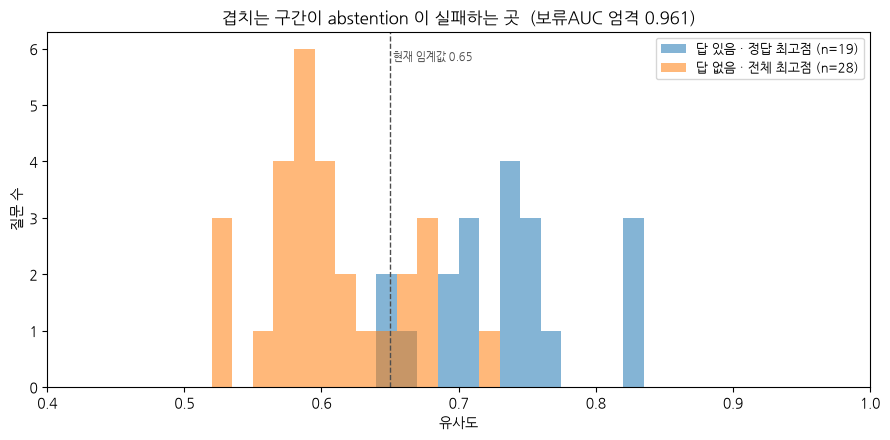

In [7]:
# 두 분포를 겹쳐 그린다 — 얼마나 겹치는지가 전부다
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(0.4, 1.0, 41)

pos_loose  = np.array([sim[qi].max() for qi, r in enumerate(relevant_idx) if r])
pos_strict = np.array([max(sim[qi][d] for d in r) for qi, r in enumerate(relevant_idx) if r])
neg        = np.array([sim[qi].max() for qi, r in enumerate(relevant_idx) if not r])

ax.hist(pos_strict, bins=bins, alpha=.55, label=f"답 있음 · 정답 최고점 (n={len(pos_strict)})")
ax.hist(neg,        bins=bins, alpha=.55, label=f"답 없음 · 전체 최고점 (n={len(neg)})")
ax.axvline(0.65, color="0.3", ls="--", lw=1)
ax.text(0.652, ax.get_ylim()[1]*.92, "현재 임계값 0.65", fontsize=8, color="0.3")
ax.set_xlim(0.4, 1.0)
ax.set_xlabel("유사도"); ax.set_ylabel("질문 수")
ax.set_title(f"겹치는 구간이 abstention 이 실패하는 곳  (보류AUC 엄격 {strict:.3f})")
ax.legend(fontsize=9)
fig.tight_layout()

print(f"답 없음 표본이 {len(neg)}개뿐이다. 이 히스토그램은 막대 {len(neg)}개로 그려진 것이고,")
print("보류여유는 그중 '최댓값 하나'가 결정한다. Phase 1 에서 이걸 늘려야 하는 이유.")

In [8]:
# 결과 저장 — 나중에 기법별 결과와 나란히 놓기 위해
Path("results").mkdir(exist_ok=True)
row = {"단계": "Phase0 베이스라인", "기법": "임베딩 단독", "표현": rep,
       "노트수": len(notes), "질문수": len(questions),
       "정답없음수": int(sum(1 for r in relevant_idx if not r)), **base}
pd.DataFrame([row]).to_csv("results/03_abstention.csv", index=False)
print(pd.DataFrame([row]).T.to_string(header=False))

단계       Phase0 베이스라인
기법             임베딩 단독
표현                 요약
노트수                21
질문수                47
정답없음수              28
AUC          0.988274
분리도          0.147982
R@1          0.947368
R@3               1.0
R@5               1.0
MRR          0.973684
최적임계값        0.644704
F1           0.454545
보류여유        -0.074804
보류AUC        0.960526
보류AUC엄격      0.960526
정답없음최고       0.719508
관련최저         0.644704

## Phase 0 판단

**모든 수치는 답 없는 질문 `n=3` 기준이다.** 아래 숫자를 인용할 때 이 조건을 빼면 안 된다.
(Phase 1 에서 28개로 늘린 뒤 상당수가 바뀐다)

| | 값 (n=3) |
|---|---|
| 보류여유 (실험②의 지표) | **−0.0256** |
| **보류AUC** 느슨 / 엄격 | **0.947 / 0.947** |
| AUC · R@3 (회귀 감시) | 0.981 · 1.000 — 검색 자체는 문제없음 |

### 판정 — "가망 없음"이 아니었다

실험②의 *"90여 설정 전부 보류여유 음수"* 는 사실 **"전부 보류AUC < 1"** 이라는 말이었다.
그런데 실제 값은 **0.947** 이다. 가망 없는 0.6 대가 아니라 **거의 다 온 상태**다.

**실패가 한 질문에 몰려 있다.** 19×3 = 57 쌍 중 뒤집힌 건 **3쌍뿐**이고,
전부 같은 질문(`LLM-as-a-judge`, 0.670) 때문이다.

```
답 없는 질문 3개
  0.670  LLM-as-a-judge 평가 파이프라인   ← 이것 하나만 뚫림
  0.644  BM25 하이브리드 + 리랭커          이미 막힘
  0.636  vLLM 서빙 + LoRA                이미 막힘
```

나머지 둘은 현재 임계값(0.65)에서 **이미 정상 작동한다.**
지표 하나를 바꿨을 뿐인데 문제의 크기가 "전면 실패"에서 "한 군데 누수"로 바뀌었다.

> 실험①에서 분리도로 판정했다가 AUC 로 뒤집힌 것과 **같은 일이 또 일어났다.**
> 그때 배운 게 *"지표가 틀리면 결론도 틀린다"* 였는데, 그 교훈을 실험②의 지표에는
> 적용하지 않고 있었다.

### 라벨 검증 — 의심은 틀렸다

0.670 이 라벨 오류일 가능성을 검사했으나, 해당 노트에 핵심 용어가 **0회**였다.
**진짜 오답이 맞다.** 임베딩이 주제만 보고 끌려온 것이다.

### 아직 못 믿는 것

- **`n=3`.** 보류AUC 0.947 도 답 없는 질문 3개로 계산했다.
  하나만 달라도 0.63 이나 1.0 으로 튄다. **실험②가 3개에 의존했던 문제가 그대로 있다.**
- 노트가 **21개**다. 실험② 당시는 20개 — 데모를 찍으며 저장한 노트가 하나 늘었다.
  AUC 0.982 → 0.981 로 차이는 미미하지만 베이스라인이 완전히 같지는 않다.

### 다음 단계

**Phase 2 의 BM25 를 먼저 싸게 확인한다 (B → A).**

0.670 을 만든 노트에 질문의 핵심 용어가 0회라는 건, **어휘 겹침으로 재면 0점**이라는 뜻이다.
가설이 맞는지 30분이면 확인되고, 결과에 따라 Phase 1 에서 만들 질문의 성격이 달라진다.

- BM25 가 통하면 → *"어휘는 안 겹치는데 주제는 같은"* 질문을 집중적으로 만든다
- 안 통하면 → 가설을 접고 리랭커·LLM 판정 쪽을 본다

그 다음 Phase 1(정답없음 질문 25개로 확장)으로 돌아온다.

---

# Phase 2-A — BM25 가설을 싸게 확인한다

Phase 0 이 남긴 단서는 이거다.

> 0.670 을 받은 노트에 질문의 핵심 용어가 **0회**다.

임베딩은 `LLM` · `아키텍처` 라는 **주제**를 보고 0.670 을 줬다.
어휘 겹침으로 재면 **0점**이 나와야 한다. 그게 맞다면 BM25 는
임베딩이 **원리적으로 볼 수 없는 신호**를 보는 것이다.

**확인할 것 세 가지**

1. 0.670 짜리 질문이 BM25 에서 정말 0점인가
2. BM25 를 섞으면 보류AUC 가 오르는가
3. **회귀 감시** — 검색 자체(AUC · R@3)가 나빠지지 않는가

BM25 는 **본문 전체**에 건다. 요약에 없어도 본문에 있을 수 있으니,
*"본문에도 없다"* 가 훨씬 강한 근거다. API 호출은 0회.

In [9]:
# 본문 전체로 BM25 — 토큰화 두 가지를 같이 본다
bodies = [n["body"] for n in notes]

bm_word  = S.bm25_matrix(questions, bodies, tokenizer=S.tok_word)
bm_ngram = S.bm25_matrix(questions, bodies, tokenizer=lambda t: S.tok_ngram(t, 2))

print(f"BM25 행렬 {bm_word.shape}  (질문 × 노트)")
print(f"  공백분리  0점인 칸 {100*(bm_word==0).mean():.1f}%")
print(f"  2-gram   0점인 칸 {100*(bm_ngram==0).mean():.1f}%")
print("\n2-gram 이 0점이 훨씬 적다 — 조각이 우연히 겹치기 때문. 변별력이 떨어질 수 있다.")

BM25 행렬 (47, 21)  (질문 × 노트)
  공백분리  0점인 칸 54.3%
  2-gram   0점인 칸 12.4%

2-gram 이 0점이 훨씬 적다 — 조각이 우연히 겹치기 때문. 변별력이 떨어질 수 있다.


In [10]:
# ① 가설 검증 — 문제의 질문이 BM25 에서 몇 점인가
print("=== 답 없는 질문 3개 · 임베딩 vs BM25(공백분리) ===\n")
for qi, (q, rel) in enumerate(zip(questions, relevant_idx)):
    if rel:
        continue
    di = int(np.argmax(sim[qi]))
    print(f"Q: {q[:58]}")
    print(f"   임베딩 1위 {sim[qi][di]:.3f}  {notes[di]['title'][:38]}")
    print(f"   └ 그 노트의 BM25 점수      {bm_word[qi][di]:.3f}")
    print(f"   BM25 1위    {bm_word[qi].max():.3f}  {notes[int(np.argmax(bm_word[qi]))]['title'][:38]}")
    print()

print("=== 답 있는 질문은? (BM25 가 정답을 잡는가) ===\n")
hit = sum(1 for qi, rel in enumerate(relevant_idx)
          if rel and int(np.argmax(bm_word[qi])) in rel)
tot = sum(1 for r in relevant_idx if r)
print(f"  BM25 단독 R@1 = {hit}/{tot} = {hit/tot:.3f}   (임베딩은 {base['R@1']:.3f})")

=== 답 없는 질문 3개 · 임베딩 vs BM25(공백분리) ===

Q: LLM-as-a-judge로 평가 파이프라인 설계하려면? 골든 데이터셋은 어떻게 만들어?
   임베딩 1위 0.670  LLM 핵심 용어 및 아키텍처 설계 가이드
   └ 그 노트의 BM25 점수      5.488
   BM25 1위    6.096  AXswgBrain: 개인 지식 RAG 챗봇 기술 설명서

Q: vLLM으로 서빙하면서 LoRA 파인튜닝하려면 PyTorch 설정을 어떻게 잡아?
   임베딩 1위 0.636  AX 엔지니어 실무 기술 스택
   └ 그 노트의 BM25 점수      0.000
   BM25 1위    4.731  LLM 핵심 용어 및 아키텍처 설계 가이드

Q: BM25랑 하이브리드 검색 붙이고 리랭커까지 태우려면 어떻게 해?
   임베딩 1위 0.644  AX 엔지니어 실무 기술 스택
   └ 그 노트의 BM25 점수      0.555
   BM25 1위    9.176  LLM 핵심 용어 및 아키텍처 설계 가이드

Q: 김치찌개에 돼지고기 대신 참치 넣어도 괜찮아?
   임베딩 1위 0.559  개발 필수 개념 및 실용 지식
   └ 그 노트의 BM25 점수      0.000
   BM25 1위    1.735  AX 엔지니어를 위한 AI 협업 개발 파이프라인

Q: 사워도우 발효종은 며칠마다 먹여야 해?
   임베딩 1위 0.532  개발 필수 개념 및 실용 지식
   └ 그 노트의 BM25 점수      0.000
   BM25 1위    4.043  LLM 핵심 용어 및 아키텍처 설계 가이드

Q: 원두는 냉동실 보관이 나아 실온이 나아?
   임베딩 1위 0.568  개발 필수 개념 및 실용 지식
   └ 그 노트의 BM25 점수      0.000
   BM25 1위    0.000  AX 엔지니어를 위한 AI 협업 개발 파이프라인

Q: 파스타 삶을 때 소금은 언제 넣는 게 맞아?
   임베딩 1위 0.532  개발 필수 개념 및 실

In [11]:
# ② 보류AUC 비교 — 단독 · 하이브리드
sim_norm = S.minmax(sim)

cands = {
    "임베딩 단독 (현재)":        sim,
    "BM25 단독 (공백분리)":      bm_word,
    "BM25 단독 (2-gram)":       bm_ngram,
    "하이브리드 RRF (임베딩+BM25)": S.rrf(sim, bm_word),
    "하이브리드 가중합 0.7/0.3":   0.7*sim_norm + 0.3*S.minmax(bm_word),
}

rows = []
for name, m in cands.items():
    r = S.evaluate(m, relevant_idx, kinds)
    rows.append({"기법": name, "보류AUC": r["보류AUC"], "보류여유": r["보류여유"],
                 "AUC": r["AUC"], "R@1": r["R@1"], "R@3": r["R@3"], "MRR": r["MRR"]})

cmp = pd.DataFrame(rows)
print(cmp.round(4).to_string(index=False))
print("\n★ 보류AUC 가 목표 지표. AUC·R@3 는 회귀 감시 — 떨어지면 안 된다.")

                  기법  보류AUC    보류여유    AUC    R@1    R@3    MRR
         임베딩 단독 (현재) 0.9605 -0.0748 0.9883 0.9474 1.0000 0.9737
      BM25 단독 (공백분리) 0.9060 -8.6494 0.9763 0.8421 0.9474 0.8965
    BM25 단독 (2-gram) 0.8929 -7.8995 0.9776 0.9474 1.0000 0.9737
하이브리드 RRF (임베딩+BM25) 0.8299 -0.0010 0.9869 0.8947 1.0000 0.9474
   하이브리드 가중합 0.7/0.3 0.8515 -0.4063 0.9775 1.0000 1.0000 1.0000

★ 보류AUC 가 목표 지표. AUC·R@3 는 회귀 감시 — 떨어지면 안 된다.


  임베딩 단독 (현재)                뒤집힌 쌍 21/532
  BM25 단독 (공백분리)             뒤집힌 쌍 73/532
  BM25 단독 (2-gram)           뒤집힌 쌍 63/532
  하이브리드 RRF (임베딩+BM25)       뒤집힌 쌍 135/532
  하이브리드 가중합 0.7/0.3          뒤집힌 쌍 109/532


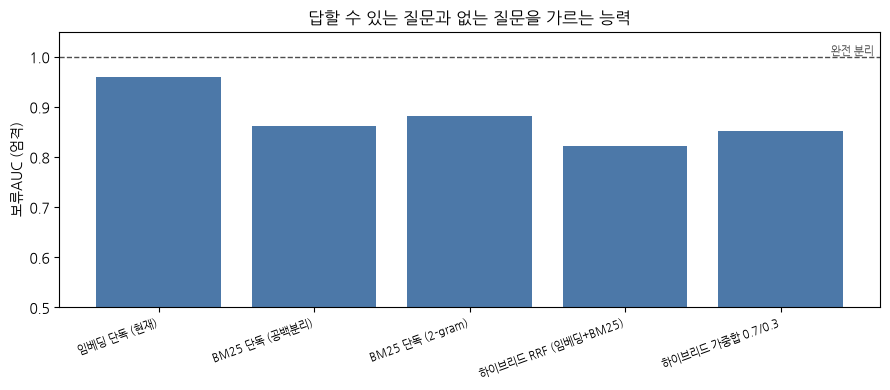

In [12]:
# ③ 어디서 갈렸나 — 답없음 최고점이 답있음 최저를 넘는 쌍을 센다
def inversions(m):
    pos = [max(m[qi][d] for d in rel) for qi, rel in enumerate(relevant_idx) if rel]
    neg = [m[qi].max() for qi, rel in enumerate(relevant_idx) if not rel]
    bad = [(p, n) for n in neg for p in pos if p <= n]
    return len(bad), len(pos)*len(neg)

for name, m in cands.items():
    b, t = inversions(m)
    print(f"  {name:26s} 뒤집힌 쌍 {b:2d}/{t}")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(cands))
ax.bar(x, [S.abstention_auc(m, relevant_idx, strict=True) for m in cands.values()], color="#4c78a8")
ax.axhline(1.0, color="0.3", ls="--", lw=1)
ax.text(len(cands)-0.4, 1.005, "완전 분리", fontsize=8, color="0.3", ha="right")
ax.set_xticks(x); ax.set_xticklabels(list(cands), rotation=20, ha="right", fontsize=8)
ax.set_ylim(0.5, 1.05); ax.set_ylabel("보류AUC (엄격)")
ax.set_title("답할 수 있는 질문과 없는 질문을 가르는 능력")
fig.tight_layout()

In [13]:
# 결과 누적 저장
prev = pd.read_csv("results/03_abstention.csv")
new = []
for name, m in cands.items():
    r = S.evaluate(m, relevant_idx, kinds)
    new.append({"단계": "Phase2A BM25확인", "기법": name, "표현": "본문전체(BM25)/요약(임베딩)",
                "노트수": len(notes), "질문수": len(questions),
                "정답없음수": int(sum(1 for r_ in relevant_idx if not r_)), **r})
out = pd.concat([prev, pd.DataFrame(new)], ignore_index=True)
out.to_csv("results/03_abstention.csv", index=False)
print(f"results/03_abstention.csv — {len(out)}행")
print(out[["단계","기법","보류AUC","보류여유","AUC","R@1"]].round(4).to_string(index=False))

results/03_abstention.csv — 6행
            단계                   기법  보류AUC    보류여유    AUC    R@1
  Phase0 베이스라인               임베딩 단독 0.9605 -0.0748 0.9883 0.9474
Phase2A BM25확인          임베딩 단독 (현재) 0.9605 -0.0748 0.9883 0.9474
Phase2A BM25확인       BM25 단독 (공백분리) 0.9060 -8.6494 0.9763 0.8421
Phase2A BM25확인     BM25 단독 (2-gram) 0.8929 -7.8995 0.9776 0.9474
Phase2A BM25확인 하이브리드 RRF (임베딩+BM25) 0.8299 -0.0010 0.9869 0.8947
Phase2A BM25확인    하이브리드 가중합 0.7/0.3 0.8515 -0.4063 0.9775 1.0000


---

# Phase 2B — 흔한 토큰을 빼고 희귀한 것만 본다

2A 가 실패한 이유는 명확했다. BM25 는 `LLM-as-a-judge` 를 `llm`·`as`·`a`·`judge` 로
쪼갰고, **`llm` 은 볼트 어디에나 있어서** 그것만으로 점수가 붙었다.

원래 직관은 살아 있다 — *"질문의 핵심 용어가 볼트에 없으면 답도 없다."*
**틀린 건 그걸 BM25 점수로 잰 것**이다. 점수는 흔한 조각까지 다 더하니까.

그래서 두 가지 신호를 따로 만든다.

| | 무엇을 보나 | 특징 |
| --- | --- | --- |
| **OOV 비율** | 질문의 내용어 중 **볼트 어디에도 없는** 비율 | 질문당 값 하나. **문서와 무관** |
| **희귀 커버리지** | 질문의 **희귀 토큰**이 이 문서에 얼마나 있나 | 질문 × 문서 |

OOV 쪽이 흥미롭다. `vllm`·`lora`·`judge`·`골든` 이 볼트에 아예 없다면,
**어느 노트와 비교하든 답은 없다.** 유사도를 재기 전에 판정할 수 있다는 뜻이다.

조사와 기능어는 뺀다 — `로`·`은`·`어떻게` 가 신호일 리 없다.

In [14]:
# 질문별 OOV 비율 — 볼트가 아예 다루지 않는 주제인가
oov = S.oov_ratio(questions, bodies)

print("=== 답 없는 질문 (높아야 정상) ===")
for qi, (q, rel) in enumerate(zip(questions, relevant_idx)):
    if not rel:
        miss = [t for t in S.content_tokens(q) if t not in S.token_df(bodies)]
        print(f"  OOV {oov[qi]:.2f}  {q[:46]}")
        print(f"           볼트에 없는 말: {miss}")

print("\n=== 답 있는 질문 중 OOV 가 높은 것 (오탐 위험) ===")
order = sorted((oov[qi], questions[qi]) for qi, r in enumerate(relevant_idx) if r)
for v, q in order[-5:][::-1]:
    print(f"  OOV {v:.2f}  {q[:56]}")
print("\n=== 답 있는 질문 평균 OOV ===")
print(f"  {np.mean([oov[qi] for qi, r in enumerate(relevant_idx) if r]):.3f}"
      f"   vs 답없음 평균 {np.mean([oov[qi] for qi, r in enumerate(relevant_idx) if not r]):.3f}")

=== 답 없는 질문 (높아야 정상) ===
  OOV 0.56  LLM-as-a-judge로 평가 파이프라인 설계하려면? 골든 데이터셋은 어떻게 만
           볼트에 없는 말: ['as', 'judge', '설계하려면', '골든', '데이터셋은']


  OOV 0.75  vLLM으로 서빙하면서 LoRA 파인튜닝하려면 PyTorch 설정을 어떻게 잡아?
           볼트에 없는 말: ['vllm', '서빙하면서', 'lora', '파인튜닝하려면', 'pytorch', '잡아']


  OOV 0.83  BM25랑 하이브리드 검색 붙이고 리랭커까지 태우려면 어떻게 해?
           볼트에 없는 말: ['bm25', '하이브리드', '붙이고', '리랭커까지', '태우려면']
  OOV 0.83  김치찌개에 돼지고기 대신 참치 넣어도 괜찮아?
           볼트에 없는 말: ['김치찌개에', '돼지고기', '참치', '넣어도', '괜찮아']


  OOV 1.00  사워도우 발효종은 며칠마다 먹여야 해?
           볼트에 없는 말: ['사워도우', '발효종은', '며칠마다', '먹여야']
  OOV 1.00  원두는 냉동실 보관이 나아 실온이 나아?
           볼트에 없는 말: ['원두는', '냉동실', '보관이', '나아', '실온이', '나아']


  OOV 0.67  파스타 삶을 때 소금은 언제 넣는 게 맞아?
           볼트에 없는 말: ['파스타', '삶을', '소금은', '맞아']
  OOV 1.00  에어프라이어로 삼겹살 구우면 몇 도에 몇 분?
           볼트에 없는 말: ['에어프라이어로', '삼겹살', '구우면', '도에']


...

  OOV 0.80  Redis 클러스터에서 키는 어떻게 분산되는 거야?


           볼트에 없는 말: ['클러스터에서', '키는', '분산되는', '거야']
  OOV 0.83  Nginx 리버스 프록시 타임아웃은 어디서 조정해?
           볼트에 없는 말: ['리버스', '프록시', '타임아웃은', '어디서', '조정해']


  OOV 0.67  벡터 인덱스 HNSW랑 IVF는 뭐가 달라?
           볼트에 없는 말: ['hnsw', 'ivf', '뭐가', '달라']


  OOV 0.71  RAG에서 청킹 크기랑 겹침은 얼마로 잡아?
           볼트에 없는 말: ['청킹', '크기랑', '겹침은', '얼마로', '잡아']
  OOV 0.33  LLM 토큰 비용 계산해서 월 예산 잡는 법
           볼트에 없는 말: ['계산해서', '잡는']
  OOV 0.60  프롬프트 인젝션 방어를 코드로 어떻게 구현해?
           볼트에 없는 말: ['인젝션', '방어를', '구현해']


  OOV 0.75  Pinecone 네임스페이스로 멀티테넌시 구성하는 법
           볼트에 없는 말: ['네임스페이스로', '멀티테넌시', '구성하는']

=== 답 있는 질문 중 OOV 가 높은 것 (오탐 위험) ===
  OOV 0.80  Obsidian 위키링크랑 백링크가 뭐가 달라?
  OOV 0.71  MSA랑 모놀리식 중에 뭘 골라야 하는지 기준이 뭐야?
  OOV 0.62  내가 만든 RAG 챗봇은 저장할 내용인지 질문인지 어떻게 구분해?
  OOV 0.56  AX 엔지니어가 정확히 뭐 하는 직무야? ML 엔지니어랑 뭐가 달라?
  OOV 0.50  임베딩이 뭐야? 글자가 달라도 뜻이 가까우면 어떻게 되는 거지?

=== 답 있는 질문 평균 OOV ===
  0.405   vs 답없음 평균 0.780


In [15]:
# OOV 단독으로 답있음/답없음을 가를 수 있나 (질문 수준 AUC)
pos_oov = np.array([oov[qi] for qi, r in enumerate(relevant_idx) if r])
neg_oov = np.array([oov[qi] for qi, r in enumerate(relevant_idx) if not r])
# OOV 는 높을수록 '답 없음' 이므로 부호를 뒤집어 비교한다
oov_auc = S.auc(-pos_oov, -neg_oov)
print(f"OOV 단독 보류AUC = {oov_auc:.4f}    (임베딩 단독 0.9474)")
print(f"  답있음 OOV 범위 {pos_oov.min():.2f} ~ {pos_oov.max():.2f}")
print(f"  답없음 OOV 범위 {neg_oov.min():.2f} ~ {neg_oov.max():.2f}")

OOV 단독 보류AUC = 0.9220    (임베딩 단독 0.9474)
  답있음 OOV 범위 0.17 ~ 0.80
  답없음 OOV 범위 0.33 ~ 1.00


In [16]:
# 희귀 커버리지 + 조합
cov = S.rare_coverage(questions, bodies)
sim_norm = S.minmax(sim)

cands2 = {
    "임베딩 단독 (현재)":            sim,
    "희귀 커버리지 단독":             cov,
    "임베딩 × 희귀커버리지":          sim_norm * (0.5 + 0.5*cov),
    "임베딩 − OOV 페널티":           sim - 0.15*oov[:, None],
    "임베딩 × (1−OOV)":            sim * (1 - oov)[:, None],
}

rows = []
for name, m in cands2.items():
    r = S.evaluate(m, relevant_idx, kinds)
    rows.append({"기법": name, "보류AUC": r["보류AUC"], "보류여유": r["보류여유"],
                 "AUC": r["AUC"], "R@1": r["R@1"], "R@3": r["R@3"]})
print(pd.DataFrame(rows).round(4).to_string(index=False))

           기법  보류AUC    보류여유    AUC    R@1    R@3
  임베딩 단독 (현재) 0.9605 -0.0748 0.9883 0.9474 1.0000
   희귀 커버리지 단독 0.5508 -1.0000 0.9446 0.7368 0.9474
 임베딩 × 희귀커버리지 0.6457 -0.5360 0.9796 1.0000 1.0000
임베딩 − OOV 페널티 0.9718 -0.1319 0.9710 0.9474 1.0000
임베딩 × (1−OOV) 0.9417 -0.3335 0.8617 0.9474 1.0000

In [17]:
# 뒤집힌 쌍으로도 확인 — 보류AUC 와 같은 방향인지
for name, m in cands2.items():
    b, t = inversions(m)
    print(f"  {name:24s} 뒤집힌 쌍 {b:2d}/{t}")

# 결과 누적
prev = pd.read_csv("results/03_abstention.csv")
new = [{"단계": "Phase2B 희귀토큰", "기법": name, "표현": "본문전체(어휘)/요약(임베딩)",
        "노트수": len(notes), "질문수": len(questions),
        "정답없음수": int(sum(1 for r_ in relevant_idx if not r_)),
        **S.evaluate(m, relevant_idx, kinds)} for name, m in cands2.items()]
out = pd.concat([prev, pd.DataFrame(new)], ignore_index=True)
out.to_csv("results/03_abstention.csv", index=False)
print(f"\nresults/03_abstention.csv — {len(out)}행")

  임베딩 단독 (현재)              뒤집힌 쌍 21/532
  희귀 커버리지 단독               뒤집힌 쌍 292/532
  임베딩 × 희귀커버리지             뒤집힌 쌍 217/532
  임베딩 − OOV 페널티            뒤집힌 쌍 15/532
  임베딩 × (1−OOV)            뒤집힌 쌍 31/532



results/03_abstention.csv — 11행


---

# Phase 1 — 답 없는 질문을 3개 → 28개로

여기까지의 모든 숫자가 **답 없는 질문 3개**에 걸려 있었다.
보류AUC 0.983 은 *"뒤집힌 쌍 1개"* 라는 뜻이고, 질문 하나만 달라도 결론이 바뀐다.

## 어떻게 결정했는가 — 결과보다 이 과정이 남을 것

**① 개수를 25개로 (총 28개)**

40개가 통계적으로는 더 안정적이다. 그런데 **질문 품질이 떨어지면 그 안정성이
오히려 잘못된 결론을 단단하게 만든다.** 표본이 크다는 이유로 틀린 결론을 믿게 되는 게
더 위험하다고 판단했다. 15개는 층당 표본이 얇아 층별 분석이 안 된다.
**25개는 "내가 품질을 통제할 수 있는 범위에서 최대"** 라는 기준으로 고른 값이다.

**② 답 있는 질문은 19개 그대로**

보류AUC 는 `답있음 × 답없음` 쌍으로 계산된다. 답없음만 늘려도
**57쌍 → 475쌍으로 8배** 안정된다. 답있음 확장은 정답 라벨링까지 필요해 비용이 두 배인데,
R@3 이 이미 1.00 이라 얻을 게 적다.

**③ 후보는 AI 가 생성하고 선택은 사람이**

AI 가 시스템 동작(임계값 0.65, OOV 신호)을 알고 있어서, 혼자 만들면
**결과가 잘 나오는 질문**을 무의식적으로 고를 수 있다. 후보만 받고 최종 선택은 사람이 했다.

**④ L1 에서 운동·건강·부동산·세금을 뺐다**

용어 검사로는 볼트에 0회였다. 그런데 **"내가 언젠가 물어볼 법한 주제"** 라
나중에 노트를 추가하면 라벨이 조용히 깨진다. 위험을 안 지고 관심 밖 주제(음식)로 대체했다.

**⑤ L2 를 더 깊은 곳으로 옮겼다**

처음엔 쿠버네티스·Kafka 를 "볼트가 안 다루는 주제"로 넣었는데, 검사해 보니
**용어 정리 노트에 한 줄씩 이미 있었다**(`Kafka 2회`, `k8s 2회`).
그래서 이들은 L2 가 아니라 **L3a**(주제는 있고 세부는 없음)로 옮기고,
L2 는 용어조차 0회인 것(Terraform·Airflow·Elasticsearch…)으로 채웠다.

**⑥ L3 를 a / b 로 쪼갰다 — 순환논리를 막기 위해**

L3 를 *"핵심 용어가 볼트에 0회"* 로만 정의하면 **OOV 신호가 자동으로 잡는다.**
그러면 "OOV 가 잘 작동한다"는 결론이 나오는데, 그건 **OOV 가 잡기 쉬운 질문만 골랐기 때문**이다.

| | 정의 | OOV 가 잡나 |
| --- | --- | --- |
| **L3a** | 상위 용어는 볼트에 **있고** 세부만 없음 | ❌ — 진짜 시험대 |
| **L3b** | 용어도 답도 없음 | ✅ — 기존 3개가 대부분 이 유형 |

**⑦ 층 배정을 감이 아니라 용어 등장 횟수로**

`트랜스포머 3회 / 어텐션 0회` → L3a.  `Terraform 0회` → L2.
사람이 "인접한 것 같다"고 정하면 시비가 붙는다. 숫자로 정하면 재현된다.

**⑧ 결과를 보고 질문을 고치지 않는다**

측정 후 마음에 안 든다고 질문을 바꾸면 **데이터에 맞춰 실험을 조정**하는 게 된다.
바꿔야 할 이유가 생기면 **왜 바꿨는지 적고** 바꾼다.

In [18]:
# 확장된 기준 데이터 로드 — 층 정보가 추가됐다
pairs = [json.loads(l) for l in Path("data/pairs.jsonl").read_text(encoding="utf-8").splitlines() if l.strip()]
questions    = [p["question"] for p in pairs]
kinds        = [p["kind"] for p in pairs]
layers       = [p.get("layer", "-") for p in pairs]
relevant_idx = [[path_to_idx[x] for x in p["relevant_paths"] if x in path_to_idx] for p in pairs]

n_pos = sum(1 for r in relevant_idx if r)
n_neg = len(pairs) - n_pos
print(f"질문 {len(pairs)}개  ·  답있음 {n_pos}  답없음 {n_neg}")
print(f"보류AUC 계산 쌍: {n_pos} × {n_neg} = {n_pos*n_neg}쌍   (이전 19×3 = 57쌍)")
print("\n층별 분포:")
for L in ("L1","L2","L3a","L3b"):
    print(f"  {L:4s} {sum(1 for l in layers if l==L)}개")

질문 47개  ·  답있음 19  답없음 28
보류AUC 계산 쌍: 19 × 28 = 532쌍   (이전 19×3 = 57쌍)

층별 분포:
  L1   5개
  L2   8개
  L3a  8개
  L3b  7개


In [19]:
# 질문 임베딩 재계산 — 새 질문 25개만 API 호출된다 (기존은 캐시)
t0 = time.time()
q_emb = S.embed_cached(client, MODEL, questions, task_type="RETRIEVAL_QUERY")
print(f"임베딩 {time.time()-t0:.1f}초 · 캐시 {S.save_cache()}건")

sim = S.aggregate(S.cosine_matrix(q_emb, doc_emb), owner, len(notes))
bm_word = S.bm25_matrix(questions, bodies, tokenizer=S.tok_word)
oov = S.oov_ratio(questions, bodies)
cov = S.rare_coverage(questions, bodies)
sim_norm = S.minmax(sim)

base28 = S.evaluate(sim, relevant_idx, kinds)
print("\n=== 베이스라인 재측정 (임베딩 단독) ===")
print(f"  보류AUC   {base28['보류AUC']:.4f}   (3개일 때 0.9474)")
print(f"  보류여유   {base28['보류여유']:+.4f}   (3개일 때 -0.0256)")
print(f"  AUC       {base28['AUC']:.4f}   R@1 {base28['R@1']:.3f}   R@3 {base28['R@3']:.3f}")

임베딩 0.0초 · 캐시 2222건

=== 베이스라인 재측정 (임베딩 단독) ===
  보류AUC   0.9605   (3개일 때 0.9474)
  보류여유   -0.0748   (3개일 때 -0.0256)
  AUC       0.9883   R@1 0.947   R@3 1.000


In [20]:
# ★ 층별로 어디까지 막히는가 — 이게 층을 나눈 이유다
print(f"{'층':5s} {'개수':>4s} {'최고점 평균':>10s} {'최고점 최대':>10s} {'0.65 통과':>9s}  {'OOV 평균':>8s}")
print("-"*62)
for L in ("L1","L2","L3a","L3b"):
    idx = [i for i,l in enumerate(layers) if l==L]
    if not idx: continue
    tops = np.array([sim[i].max() for i in idx])
    thru = int((tops >= 0.65).sum())
    print(f"{L:5s} {len(idx):>4d} {tops.mean():>10.3f} {tops.max():>10.3f} {thru:>6d}/{len(idx)}  {oov[idx].mean():>8.3f}")

pos_top = np.array([max(sim[i][d] for d in r) for i,r in enumerate(relevant_idx) if r])
print(f"\n답있음 {len(pos_top)}개  정답최고점 평균 {pos_top.mean():.3f}  최저 {pos_top.min():.3f}")
print(f"→ 답있음 최저({pos_top.min():.3f})보다 높은 답없음 질문: "
      f"{sum(1 for i,l in enumerate(layers) if l!='-' and sim[i].max() > pos_top.min())}개")

층       개수     최고점 평균     최고점 최대   0.65 통과    OOV 평균
--------------------------------------------------------------
L1       5      0.543      0.568      0/5     0.900
L2       8      0.590      0.608      0/8     0.790
L3a      8      0.605      0.670      1/8     0.796
L3b      7      0.669      0.720      5/7     0.664

답있음 19개  정답최고점 평균 0.733  최저 0.647
→ 답있음 최저(0.647)보다 높은 답없음 질문: 6개


In [21]:
# 기법 재비교 — 질문 28개 기준
cands3 = {
    "임베딩 단독 (현재)":      sim,
    "BM25 단독":            bm_word,
    "하이브리드 RRF":         S.rrf(sim, bm_word),
    "임베딩 × 희귀커버리지":     sim_norm*(0.5+0.5*cov),
    "임베딩 − OOV 페널티":     sim - 0.15*oov[:, None],
}
rows=[]
for name, m in cands3.items():
    r = S.evaluate(m, relevant_idx, kinds)
    b, t = inversions(m)
    rows.append({"기법": name, "보류AUC": r["보류AUC"], "보류여유": r["보류여유"],
                 "AUC": r["AUC"], "R@1": r["R@1"], "R@3": r["R@3"], "뒤집힌쌍": f"{b}/{t}"})
comp = pd.DataFrame(rows)
print(comp.round(4).to_string(index=False))

           기법  보류AUC    보류여유    AUC    R@1    R@3    뒤집힌쌍
  임베딩 단독 (현재) 0.9605 -0.0748 0.9883 0.9474 1.0000  21/532
      BM25 단독 0.9060 -8.6494 0.9763 0.8421 0.9474  73/532
    하이브리드 RRF 0.8299 -0.0010 0.9869 0.8947 1.0000 135/532
 임베딩 × 희귀커버리지 0.6457 -0.5360 0.9796 1.0000 1.0000 217/532
임베딩 − OOV 페널티 0.9718 -0.1319 0.9710 0.9474 1.0000  15/532


In [22]:
# 층별 × 기법별 — 어느 기법이 어느 층에서 무너지나
#
# ★ 처음엔 minmax 정규화 후 비교했다가 표가 전부 '누수'로 나왔다.
#   minmax 는 **행별(질문별)** 정규화라 모든 질문의 최댓값이 1.0 이 된다.
#   그러면 "답없음 최고점 > 답있음 최저점" 이 거의 항상 참이 되어 비교가 무의미해진다.
#   → 각 기법의 **원점수 안에서** 비교해야 한다. 기법끼리는 스케일이 달라 비교 불가.
print(f"{'기법':22s} " + " ".join(f"{L:>8s}" for L in ("L1","L2","L3a","L3b")) + "   누수합")
print("-"*68)
for name, m in cands3.items():
    pos_min = min(max(m[i][d] for d in r) for i, r in enumerate(relevant_idx) if r)
    cells, total = [], 0
    for L in ("L1","L2","L3a","L3b"):
        idx = [i for i, l in enumerate(layers) if l == L]
        leak = sum(1 for i in idx if m[i].max() > pos_min)
        total += leak
        cells.append(f"{leak}/{len(idx)}")
    print(f"{name:22s} " + " ".join(f"{c:>8s}" for c in cells) + f"   {total:>4d}/28")
print("\n(각 기법의 원점수 기준. 답있음 최저점을 넘어버린 질문 수 / 그 층의 질문 수)")

# 누적 저장
prev = pd.read_csv("results/03_abstention.csv")
prev = prev[prev["단계"] != "Phase1 확장(28)"]
new = [{"단계":"Phase1 확장(28)", "기법":name, "표현":"본문전체(어휘)/요약(임베딩)",
        "노트수":len(notes), "질문수":len(questions), "정답없음수":n_neg,
        **S.evaluate(m, relevant_idx, kinds)} for name, m in cands3.items()]
pd.concat([prev, pd.DataFrame(new)], ignore_index=True).to_csv("results/03_abstention.csv", index=False)
print("results/03_abstention.csv 갱신")

기법                           L1       L2      L3a      L3b   누수합
--------------------------------------------------------------------
임베딩 단독 (현재)                 0/5      0/8      1/8      5/7      6/28
BM25 단독                     3/5      7/8      8/8      7/7     25/28
하이브리드 RRF                   4/5      6/8      7/8      6/7     23/28
임베딩 × 희귀커버리지                2/5      5/8      5/8      5/7     17/28
임베딩 − OOV 페널티               0/5      0/8      1/8      5/7      6/28

(각 기법의 원점수 기준. 답있음 최저점을 넘어버린 질문 수 / 그 층의 질문 수)


results/03_abstention.csv 갱신


---

# Phase 1-B — 왜 L3b 만 뚫리나

층 정의는 틀렸지만 **누수가 한 층에 몰려 있다**는 사실은 남았다.
6개 중 5개가 L3b 다. 그 5개의 공통점을 찾는다.

지금 가설: **질문이 볼트의 중심 주제어를 달고 있으면, 세부를 몰라도 점수가 높다.**

원인은 두 쪽에 있을 수 있다.
- **질문 쪽** — L3b 질문이 흔한 주제어를 많이 쓴다
- **노트 쪽** — 특정 노트가 "무엇이든 끌어당기는 자석"이다

둘 다 본다. 원인을 모르고 리랭커부터 붙이면 2A 때처럼 또 헛다리를 짚는다.

In [23]:
# ① 뚫린 질문은 정확히 무엇이고, 무엇에 걸렸나
pos_min = min(max(sim[i][d] for d in r) for i, r in enumerate(relevant_idx) if r)
print(f"답있음 최저점 = {pos_min:.3f}  (이걸 넘으면 누수)\n")

leaked = []
for i, l in enumerate(layers):
    if l == "-" or sim[i].max() <= pos_min:
        continue
    di = int(np.argmax(sim[i]))
    leaked.append((l, sim[i].max(), questions[i], notes[di]["title"], di))

for l, s, q, t, di in sorted(leaked, key=lambda x: -x[1]):
    print(f"[{l}] {s:.3f}  {q[:44]}")
    print(f"        → {t[:52]}")
print(f"\n총 {len(leaked)}개 누수")

답있음 최저점 = 0.647  (이걸 넘으면 누수)

[L3b] 0.720  LLM 토큰 비용 계산해서 월 예산 잡는 법
        → LLM 핵심 용어 및 아키텍처 설계 가이드
[L3b] 0.683  프롬프트 인젝션 방어를 코드로 어떻게 구현해?
        → LLM 핵심 용어 및 아키텍처 설계 가이드
[L3b] 0.683  Pinecone 네임스페이스로 멀티테넌시 구성하는 법
        → AX 엔지니어 실무 기술 스택
[L3a] 0.670  LLM-as-a-judge로 평가 파이프라인 설계하려면? 골든 데이터셋은 어떻게
        → LLM 핵심 용어 및 아키텍처 설계 가이드
[L3b] 0.661  벡터 인덱스 HNSW랑 IVF는 뭐가 달라?
        → 임베딩
[L3b] 0.657  RAG에서 청킹 크기랑 겹침은 얼마로 잡아?
        → AX 엔지니어 실무 기술 스택

총 6개 누수


In [24]:
# ② 자석 노트가 있나 — 답없음 질문의 1위로 몇 번 잡혔는지
from collections import Counter
neg_idx = [i for i, l in enumerate(layers) if l != "-"]
top1 = Counter(int(np.argmax(sim[i])) for i in neg_idx)

print(f"{'노트':46s} {'1위횟수':>6s} {'본문':>7s} {'요약':>6s}")
print("-"*70)
for di, cnt in top1.most_common(8):
    n = notes[di]
    print(f"{n['title'][:44]:46s} {cnt:>6d} {len(n['body']):>6,}자 {len(n['summary']):>5,}자")

print(f"\n답없음 질문 {len(neg_idx)}개가 노트 {len(top1)}개에 몰려 있다 (전체 {len(notes)}개 중)")

노트                                               1위횟수      본문     요약
----------------------------------------------------------------------
개발 필수 개념 및 실용 지식                                    8  2,699자   235자
AX 엔지니어 실무 기술 스택                                    6  1,765자   352자
개발 & 아키텍처 설계 용어 정리                                  4  3,730자   210자
LLM 핵심 용어 및 아키텍처 설계 가이드                             3  2,264자   261자
백엔드 기술 스택 및 실무 판단 규칙 정리                             3  7,714자   325자
임베딩                                                 2    672자   219자
AX 엔지니어를 위한 AI 협업 개발 파이프라인                          1  2,964자   300자
Python 핵심 라이브러리 및 기술 스택 정리                          1  2,844자   290자

답없음 질문 28개가 노트 8개에 몰려 있다 (전체 21개 중)


In [25]:
# ③ 노트 쪽 원인 — 요약이 길수록 자석인가
mag = np.array([top1.get(i, 0) for i in range(len(notes))])
slen = np.array([len(n["summary"]) for n in notes])
blen = np.array([len(n["body"]) for n in notes])
# 모든 답없음 질문에 대한 평균 점수 = '기본적으로 잘 걸리는 정도'
avg_neg = sim[neg_idx].mean(axis=0)

print(f"자석횟수 vs 요약길이   상관 {np.corrcoef(mag, slen)[0,1]:+.3f}")
print(f"자석횟수 vs 본문길이   상관 {np.corrcoef(mag, blen)[0,1]:+.3f}")
print(f"평균점수 vs 요약길이   상관 {np.corrcoef(avg_neg, slen)[0,1]:+.3f}\n")

order = np.argsort(-avg_neg)[:6]
print(f"{'답없음 질문에 대한 평균점수 상위':46s} {'평균':>6s} {'요약':>6s} {'자석':>4s}")
print("-"*68)
for di in order:
    print(f"{notes[di]['title'][:44]:46s} {avg_neg[di]:>6.3f} {len(notes[di]['summary']):>5,}자 {mag[di]:>4d}")

자석횟수 vs 요약길이   상관 -0.168
자석횟수 vs 본문길이   상관 -0.142
평균점수 vs 요약길이   상관 -0.193

답없음 질문에 대한 평균점수 상위                                 평균     요약   자석
--------------------------------------------------------------------
AX 엔지니어 실무 기술 스택                                0.586   352자    6
백엔드 기술 스택 및 실무 판단 규칙 정리                         0.583   325자    3
Python 핵심 라이브러리 및 기술 스택 정리                      0.580   290자    1
개발 필수 개념 및 실용 지식                                0.578   235자    8
개발 & 아키텍처 설계 용어 정리                              0.574   210자    4
LLM 핵심 용어 및 아키텍처 설계 가이드                         0.569   261자    3


In [26]:
# ④ 질문 쪽 원인 — 층별로 얼마나 '흔한 말'을 쓰나
df = S.token_df(bodies)
N = len(bodies)

def q_stats(i):
    toks = S.content_tokens(questions[i])
    if not toks: return 0.0, 0.0
    in_vault = [t for t in toks if t in df]
    if not in_vault: return 0.0, 0.0
    # 볼트에 있는 토큰이 평균 몇 개 문서에 퍼져 있나 (높을수록 흔한 말)
    spread = np.mean([df[t] / N for t in in_vault])
    return spread, len(in_vault) / len(toks)

print(f"{'층':5s} {'개수':>4s} {'볼트어휘 비율':>12s} {'그 어휘의 흔함':>13s} {'최고점 평균':>10s}")
print("-"*54)
for L in ("L1","L2","L3a","L3b"):
    idx = [i for i, l in enumerate(layers) if l == L]
    sp = np.mean([q_stats(i)[0] for i in idx])
    cv = np.mean([q_stats(i)[1] for i in idx])
    tops = np.mean([sim[i].max() for i in idx])
    print(f"{L:5s} {len(idx):>4d} {cv:>12.3f} {sp:>13.3f} {tops:>10.3f}")

idx_pos = [i for i, r in enumerate(relevant_idx) if r]
sp = np.mean([q_stats(i)[0] for i in idx_pos]); cv = np.mean([q_stats(i)[1] for i in idx_pos])
print(f"{'답있음':5s} {len(idx_pos):>4d} {cv:>12.3f} {sp:>13.3f} "
      f"{np.mean([max(sim[i][d] for d in relevant_idx[i]) for i in idx_pos]):>10.3f}")
print("\n'그 어휘의 흔함' = 질문이 쓴 볼트 어휘가 평균 몇 %의 노트에 퍼져 있나")

층       개수      볼트어휘 비율      그 어휘의 흔함     최고점 평균
------------------------------------------------------
L1       5        0.100         0.038      0.543
L2       8        0.210         0.115      0.590
L3a      8        0.204         0.168      0.605
L3b      7        0.336         0.299      0.669
답있음     19        0.595         0.162      0.733

'그 어휘의 흔함' = 질문이 쓴 볼트 어휘가 평균 몇 %의 노트에 퍼져 있나


답없음 28개 안에서
  최고점 vs 어휘의 흔함   상관 +0.591
  최고점 vs 볼트어휘 비율  상관 +0.579
  최고점 vs OOV          상관 -0.579


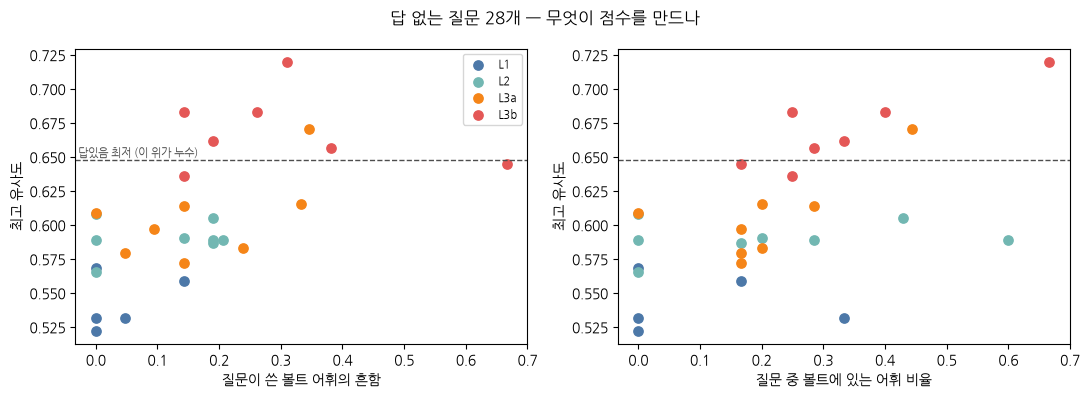

In [27]:
# ⑤ 상관 확인 — '흔한 말을 쓸수록 점수가 높다'가 맞나
neg_spread = np.array([q_stats(i)[0] for i in neg_idx])
neg_top    = np.array([sim[i].max() for i in neg_idx])
neg_cov    = np.array([q_stats(i)[1] for i in neg_idx])

print(f"답없음 {len(neg_idx)}개 안에서")
print(f"  최고점 vs 어휘의 흔함   상관 {np.corrcoef(neg_spread, neg_top)[0,1]:+.3f}")
print(f"  최고점 vs 볼트어휘 비율  상관 {np.corrcoef(neg_cov, neg_top)[0,1]:+.3f}")
print(f"  최고점 vs OOV          상관 {np.corrcoef(oov[neg_idx], neg_top)[0,1]:+.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
cols = {"L1":"#4c78a8","L2":"#72b7b2","L3a":"#f58518","L3b":"#e45756"}
for L in ("L1","L2","L3a","L3b"):
    ii = [k for k, i in enumerate(neg_idx) if layers[i] == L]
    ax[0].scatter(neg_spread[ii], neg_top[ii], c=cols[L], label=L, s=45)
    ax[1].scatter(neg_cov[ii], neg_top[ii], c=cols[L], label=L, s=45)
for a, xl in zip(ax, ["질문이 쓴 볼트 어휘의 흔함", "질문 중 볼트에 있는 어휘 비율"]):
    a.axhline(pos_min, color="0.3", ls="--", lw=1)
    a.set_xlabel(xl); a.set_ylabel("최고 유사도")
ax[0].text(ax[0].get_xlim()[0], pos_min+0.003, " 답있음 최저 (이 위가 누수)", fontsize=8, color="0.3")
ax[0].legend(fontsize=8)
fig.suptitle("답 없는 질문 28개 — 무엇이 점수를 만드나")
fig.tight_layout()

## Phase 1-B 결론 — 누수는 "넓고 얕은 질문 × 넓고 얕은 노트"

### 노트 쪽 — 자석은 **용어 정리 노트**다

| 노트 | 답없음 질문의 1위가 된 횟수 |
| --- | --- |
| 개발 필수 개념 및 실용 지식 | 8 |
| AX 엔지니어 실무 기술 스택 | 6 |
| 개발 & 아키텍처 설계 용어 정리 | 4 |
| LLM 핵심 용어 및 아키텍처 설계 가이드 | 3 |
| 백엔드 기술 스택 및 실무 판단 규칙 정리 | 3 |

상위 5개가 **전부 "용어/스택 정리"** 노트다. 한 노트가 수십 개 용어를 **얕게 나열**해서
**어떤 기술 질문이든 조금씩 걸린다.**

누수 6개 중 5개가 이 중 두 노트에 몰렸다.
`LLM 핵심 용어` 3개 · `AX 실무 기술 스택` 2개.

### 길이는 원인이 아니었다 — 예상이 틀렸다

```
자석횟수 vs 요약길이   −0.168
자석횟수 vs 본문길이   −0.142
```

**긴 노트가 자석일 것**이라 예상했다. 볼트에 47,813자짜리 RAG 설명서가 있어서
"RAG 관련이면 뭐든 걸리는" 자석일 거라 봤는데, **상위 8개에 들지도 못했다.**
오히려 약한 **음의** 상관이다. 길이가 아니라 **내용의 폭**이 문제였다.

### 질문 쪽 — L3b 는 "어디에나 있는 말"을 쓴다

| 층 | 볼트 어휘 비율 | 그 어휘의 흔함 | 최고점 평균 |
| --- | --- | --- | --- |
| L1 | 0.100 | 0.038 | 0.543 |
| L2 | 0.210 | 0.115 | 0.590 |
| L3a | 0.204 | 0.168 | 0.605 |
| **L3b** | 0.336 | **0.299** | **0.669** |
| 답있음 | **0.595** | 0.162 | 0.733 |

★ **답있음과 L3b 의 차이가 어휘의 양이 아니라 어휘의 성격이다.**

- **답있음** — 볼트 어휘를 많이 쓰고(0.595), 그 어휘가 **좁게 퍼져 있다**(0.162).
  즉 **특정 노트를 지목하는 말**을 쓴다.
- **L3b** — 볼트 어휘는 적게 쓰지만(0.336), 그 어휘가 **넓게 퍼져 있다**(0.299).
  `LLM` · `RAG` · `Pinecone` · `벡터` — **아무 노트나 걸리는 말**이다.

상관으로도 확인된다.

```
최고점 vs 어휘의 흔함    +0.591
최고점 vs 볼트어휘 비율   +0.579
최고점 vs OOV          −0.579
```

### 그래서 어휘 신호로는 못 푼다

2A(BM25)와 2B(OOV·희귀커버리지)가 실패한 이유가 여기서 설명된다.
**L3b 질문은 볼트 어휘를 실제로 쓴다.** 없는 말을 찾는 신호로는 잡을 수 없다.

남은 건 **질문과 문서를 같이 보는 것** — 크로스인코더 리랭커, 또는 LLM 판정이다.
`LLM 핵심 용어` 노트에 *"프롬프트 인젝션 방어를 코드로 구현하는 법"* 이 없다는 건
**두 텍스트를 나란히 놓고 봐야** 알 수 있다.

### 다음에 재볼 것

- 리랭커가 "넓고 얕은 노트"를 실제로 걸러내는가
- 노트 쪽 처방도 가능하다 — 용어 정리 노트를 **용어별로 쪼개면** 자석 효과가 줄어들까
  (실험②에서 청킹을 "이득 대비 비용 3.75배"로 보류했는데, **abstention 관점에서는 다시 볼 값어치가 있다.**
  그때는 검색 품질만 봤다)

---

# Phase 2B-2 — OOV 페널티의 이득은 어느 층에서 왔나

`− OOV 페널티` 는 28개 기준에서도 살아남은 유일한 기법이다
(보류AUC 0.9605 → 0.9718, 뒤집힌 쌍 21 → 15).

**그 +0.011 이 어디서 왔는지** 층별로 쪼갠다. 새로 잴 건 없고 집계만 한다.

이걸 봐야 하는 이유: 이득이 L1·L2(이미 잘 막히는 층)에서만 왔다면 **쓸모가 없다.**
진짜 문제는 L3b 니까.

In [28]:
# 층별 기여 분해 — 뒤집힌 쌍이 어느 층에서 줄었나
def pairs_by_layer(m):
    """층별로 (답있음 정답점수 <= 답없음 최고점) 인 쌍의 수를 센다."""
    pos = [max(m[i][d] for d in r) for i, r in enumerate(relevant_idx) if r]
    out = {}
    for L in ("L1","L2","L3a","L3b"):
        idx = [i for i, l in enumerate(layers) if l == L]
        bad = sum(1 for i in idx for p in pos if p <= m[i].max())
        out[L] = (bad, len(idx) * len(pos))
    return out

base_m = sim
oov_m  = sim - 0.15 * oov[:, None]

b, o = pairs_by_layer(base_m), pairs_by_layer(oov_m)
print(f"{'층':5s} {'임베딩 단독':>12s} {'− OOV 페널티':>14s} {'변화':>8s}")
print("-"*46)
tb = to = 0
for L in ("L1","L2","L3a","L3b"):
    bb, tot = b[L]; oo, _ = o[L]
    tb += bb; to += oo
    print(f"{L:5s} {f'{bb}/{tot}':>12s} {f'{oo}/{tot}':>14s} {oo-bb:>+8d}")
print("-"*46)
print(f"{'합계':5s} {f'{tb}/532':>12s} {f'{to}/532':>14s} {to-tb:>+8d}")
print(f"\n보류AUC  {S.abstention_auc(base_m, relevant_idx, strict=True):.4f}"
      f" → {S.abstention_auc(oov_m, relevant_idx, strict=True):.4f}")

층           임베딩 단독      − OOV 페널티       변화
----------------------------------------------
L1            0/95           0/95       +0
L2           0/152          0/152       +0
L3a          3/152          1/152       -2
L3b         18/133         14/133       -4
----------------------------------------------
합계          21/532         15/532       -6

보류AUC  0.9605 → 0.9718


In [29]:
# 질문 하나하나가 얼마나 밀려났나 — 페널티는 OOV 에 비례한다
delta = -0.15 * oov          # 각 질문이 받은 페널티
print(f"{'층':5s} {'개수':>4s} {'평균 페널티':>11s} {'원래 최고점':>11s} {'페널티 후':>10s}")
print("-"*48)
for L in ("L1","L2","L3a","L3b"):
    idx = [i for i, l in enumerate(layers) if l == L]
    print(f"{L:5s} {len(idx):>4d} {delta[idx].mean():>11.4f} "
          f"{np.mean([sim[i].max() for i in idx]):>11.3f} "
          f"{np.mean([sim[i].max()+delta[i] for i in idx]):>10.3f}")
ip = [i for i, r in enumerate(relevant_idx) if r]
print(f"{'답있음':5s} {len(ip):>4d} {delta[ip].mean():>11.4f} "
      f"{np.mean([max(sim[i][d] for d in relevant_idx[i]) for i in ip]):>11.3f} "
      f"{np.mean([max(sim[i][d] for d in relevant_idx[i])+delta[i] for i in ip]):>10.3f}")

print("\n★ 답있음도 같이 깎인다. 순이득은 '답없음이 더 많이 깎이는 만큼' 뿐이다.")
print(f"  답없음 평균 페널티 {delta[[i for i,l in enumerate(layers) if l!='-']].mean():.4f}")
print(f"  답있음 평균 페널티 {delta[ip].mean():.4f}")

층       개수      평균 페널티      원래 최고점      페널티 후
------------------------------------------------
L1       5     -0.1350       0.543      0.408
L2       8     -0.1185       0.590      0.472
L3a      8     -0.1194       0.605      0.485
L3b      7     -0.0996       0.669      0.569
답있음     19     -0.0608       0.733      0.672

★ 답있음도 같이 깎인다. 순이득은 '답없음이 더 많이 깎이는 만큼' 뿐이다.
  답없음 평균 페널티 -0.1170
  답있음 평균 페널티 -0.0608


## Phase 2B-2 판단

### 이득은 전부 어려운 층에서 왔다

| 층 | 임베딩 단독 | − OOV 페널티 | 변화 |
| --- | --- | --- | --- |
| L1 | 0/95 | 0/95 | +0 |
| L2 | 0/152 | 0/152 | +0 |
| L3a | 3/152 | 1/152 | **−2** |
| L3b | 18/133 | 14/133 | **−4** |
| 합계 | 21/532 | 15/532 | **−6** |

L1·L2 는 원래 0 이라 개선할 것이 없었다. **+0.011 은 전부 L3a·L3b 에서 왔다.**
"쉬운 층에서만 좋아진 것 아니냐"는 의심은 기각된다.

### 그런데 정확히 필요한 곳에서 제일 약하다

| 층 | 평균 페널티 |
| --- | --- |
| L1 | −0.1350 |
| L2 | −0.1185 |
| L3a | −0.1194 |
| **L3b** | **−0.0996** |
| 답있음 | −0.0608 |

**L3b 가 답없음 중 가장 적게 깎인다.** 이유는 Phase 1-B 에서 이미 나왔다 —
L3b 는 볼트 어휘를 많이 쓰니 OOV 가 낮고, 페널티는 OOV 에 비례하므로 작아진다.

> OOV 페널티는 **이미 잘 막히는 것을 더 세게 밀고, 안 막히는 것은 약하게 민다.**
> 방향은 맞지만 **강도가 문제와 반비례한다.**

그래서 L3b 누수가 18 → 14 로 **22% 만** 줄었다. 주된 문제는 그대로다.

### 그리고 답있음도 같이 깎인다

```
답없음 평균 페널티  −0.1170
답있음 평균 페널티  −0.0608
```

순이득은 **차이(0.056)** 뿐이다. 페널티 계수를 키우면 답있음도 같이 무너진다.
`0.15` 를 튜닝해도 이 구조는 안 바뀐다 — **비례 관계 자체가 문제**이기 때문이다.

### 결론

`− OOV 페널티` 는 **채택할 만하지만 해결책이 아니다.**
- 검색 순위를 안 건드리고(질문별 상수) 보류AUC 를 0.9605 → 0.9718 로 올린다
- 비용 0. 로컬 계산이고 API 호출이 없다
- 그러나 **L3b 를 22% 밖에 못 줄인다**

남은 78% 는 어휘로 설명되지 않는다. Phase 1-B 의 진단대로
**질문과 문서를 같이 보는 수단**(크로스인코더 · LLM 판정)이 필요하다.

---

# Phase 2C — LLM 판정

Phase 1-B 의 진단은 이랬다.

> 누수는 **넓고 얕은 질문 × 넓고 얕은 노트** 에서 난다.
> L3b 질문은 볼트 어휘를 실제로 쓰므로 어휘 신호로는 못 잡는다.
> 남은 건 **질문과 문서를 같이 보는 수단**이다.

LLM 판정은 그중 가장 직접적이다. *"이 노트에 이 질문의 답이 실제로 적혀 있나"* 를 그냥 묻는다.
**유일하게 "주제가 비슷한가"가 아니라 "답이 있는가"를 재는 수단**이다.

## 설계

- **상위 5개에만 건다.** 21개 전부에 걸면 비용이 4배고, R@3 = 1.00 이라 정답은 상위 3개 안에 있다.
- **노트 본문을 통째로 넣는다.** 요약으로 판정하면 *"요약에 없을 뿐"* 인 것을
  *"답이 없다"* 로 잘못 판정한다 — small-to-big 의 답변 단계와 같은 이유다.
- **캐시한다.** 실험②의 교훈 ⑦ — 캐시 없으면 반복 실험 자체가 불가능하다.

호출 수: 질문 47개 × 상위 5개 = **235회**.

In [30]:
S.load_judge_cache()
JUDGE_MODEL = "gemini-2.5-flash"
TOPK_JUDGE = 5

# 상위 5개만 뽑아 (질문, 노트본문) 쌍 만들기
top_idx = np.argsort(-sim, axis=1)[:, :TOPK_JUDGE]
qd_pairs, where = [], []
for qi in range(len(questions)):
    for di in top_idx[qi]:
        qd_pairs.append((questions[qi], notes[di]["body"]))
        where.append((qi, int(di)))

print(f"판정할 쌍 {len(qd_pairs)}개 (질문 {len(questions)} × 상위 {TOPK_JUDGE})")
t0 = time.time()
scores = S.judge_pairs(client, JUDGE_MODEL, qd_pairs, log=print)
print(f"완료 {time.time()-t0:.0f}초 · 캐시 {S.save_judge_cache()}건")

# 판정 점수를 (질문 × 노트) 행렬로. 판정 안 한 칸은 0
judge = np.zeros_like(sim)
for (qi, di), s_ in zip(where, scores):
    judge[qi, di] = s_ / 10.0
print(f"판정 점수 범위 {judge.max():.2f} ~ {judge[judge>0].min():.2f}")

판정할 쌍 235개 (질문 47 × 상위 5)
완료 0초 · 캐시 235건
판정 점수 범위 1.00 ~ 0.20


In [31]:
# 판정만으로 답있음/답없음을 가를 수 있나
jt_pos = np.array([judge[i].max() for i, r in enumerate(relevant_idx) if r])
jt_neg = np.array([judge[i].max() for i, r in enumerate(relevant_idx) if not r])
print(f"판정 최고점  답있음 평균 {jt_pos.mean():.3f} (최저 {jt_pos.min():.2f})")
print(f"            답없음 평균 {jt_neg.mean():.3f} (최고 {jt_neg.max():.2f})")
print(f"\n보류AUC (판정 단독) = {S.abstention_auc(judge, relevant_idx, strict=True):.4f}")

print("\n=== 층별 판정 최고점 ===")
for L in ("L1","L2","L3a","L3b"):
    idx=[i for i,l in enumerate(layers) if l==L]
    print(f"  {L:4s} 평균 {np.mean([judge[i].max() for i in idx]):.3f}  "
          f"최고 {max(judge[i].max() for i in idx):.2f}")

판정 최고점  답있음 평균 0.874 (최저 0.00)
            답없음 평균 0.029 (최고 0.50)

보류AUC (판정 단독) = 0.9154

=== 층별 판정 최고점 ===
  L1   평균 0.000  최고 0.00
  L2   평균 0.000  최고 0.00
  L3a  평균 0.000  최고 0.00
  L3b  평균 0.114  최고 0.50


In [32]:
# 조합 비교 — 판정을 어떻게 쓰는 게 좋은가
cands4 = {
    "임베딩 단독 (현재)":       sim,
    "− OOV 페널티 (2B 최선)":  sim - 0.15*oov[:, None],
    "LLM 판정 단독":           judge,
    "임베딩 × 판정":            sim * (0.3 + 0.7*judge),
    "임베딩 + 판정 게이트":       np.where(judge >= 0.3, sim, sim - 0.15),
}
rows=[]
for name, m in cands4.items():
    r = S.evaluate(m, relevant_idx, kinds)
    b, t = inversions(m)
    rows.append({"기법": name, "보류AUC": r["보류AUC"], "AUC": r["AUC"],
                 "R@1": r["R@1"], "R@3": r["R@3"], "뒤집힌쌍": f"{b}/{t}"})
print(pd.DataFrame(rows).round(4).to_string(index=False))

print("\n=== 층별 누수 ===")
print(f"{'기법':22s} " + " ".join(f"{L:>8s}" for L in ("L1","L2","L3a","L3b")) + "   합")
for name, m in cands4.items():
    pmin = min(max(m[i][d] for d in r) for i,r in enumerate(relevant_idx) if r)
    cells, tot = [], 0
    for L in ("L1","L2","L3a","L3b"):
        idx=[i for i,l in enumerate(layers) if l==L]
        leak=sum(1 for i in idx if m[i].max() > pmin); tot+=leak
        cells.append(f"{leak}/{len(idx)}")
    print(f"{name:22s} " + " ".join(f"{c:>8s}" for c in cells) + f"  {tot:>3d}/28")

               기법  보류AUC    AUC    R@1    R@3   뒤집힌쌍
      임베딩 단독 (현재) 0.9605 0.9883 0.9474 1.0000 21/532
− OOV 페널티 (2B 최선) 0.9718 0.9710 0.9474 1.0000 15/532
        LLM 판정 단독 0.9436 0.8972 0.7368 0.8421 84/532
         임베딩 × 판정 0.9850 0.9922 0.9474 1.0000 10/532
     임베딩 + 판정 게이트 0.9699 0.9906 0.9474 1.0000 17/532

=== 층별 누수 ===
기법                           L1       L2      L3a      L3b   합
임베딩 단독 (현재)                 0/5      0/8      1/8      5/7    6/28
− OOV 페널티 (2B 최선)           0/5      0/8      1/8      5/7    6/28
LLM 판정 단독                   0/5      0/8      0/8      2/7    2/28
임베딩 × 판정                    0/5      0/8      1/8      5/7    6/28
임베딩 + 판정 게이트                0/5      0/8      1/8      5/7    6/28


### 판정이 틀린 곳을 본다

`판정 단독` 은 답없음 28개 중 **26개를 0점**으로 정확히 걸렀다. L1·L2·L3a 는 전부 0.000 이다.
그런데 보류AUC 는 0.9436 으로 임베딩 단독(0.9605)보다 **낮다.**

이유는 **답있음 최저가 0.00** 이기 때문이다 — 답이 있는데 LLM 이 "없다"고 판정한 질문이 있다.
하나의 오판이 지표 전체를 끌어내린다. **그게 무엇인지 봐야 한다.**

In [33]:
# 답이 있는데 판정이 낮은 질문 — 오판 사례
print("=== 답있음인데 판정 최고점이 낮은 순 ===\n")
rows = []
for i, r in enumerate(relevant_idx):
    if not r: continue
    rows.append((judge[i].max(), max(judge[i][d] for d in r), sim[i].max(), questions[i], i))
for jmax, jrel, s_, q, i in sorted(rows)[:5]:
    print(f"판정 전체최고 {jmax:.2f} / 정답노트 판정 {jrel:.2f} / 임베딩 {s_:.3f}")
    print(f"  Q: {q}")
    for di in np.argsort(-sim[i])[:3]:
        tag = "★정답" if di in relevant_idx[i] else "     "
        print(f"     {tag} 임베딩 {sim[i][di]:.3f} 판정 {judge[i][di]:.2f}  {notes[di]['title'][:40]}")
    print()

print("=== 답없음인데 판정이 높은 2개 (남은 누수) ===\n")
for i, l in enumerate(layers):
    if l == "-" or judge[i].max() < 0.3: continue
    di = int(np.argmax(judge[i]))
    print(f"[{l}] 판정 {judge[i].max():.2f} · 임베딩 {sim[i][di]:.3f}")
    print(f"  Q: {questions[i][:52]}")
    print(f"     → {notes[di]['title'][:46]}\n")

=== 답있음인데 판정 최고점이 낮은 순 ===

판정 전체최고 0.00 / 정답노트 판정 0.00 / 임베딩 0.647
  Q: MSA랑 모놀리식 중에 뭘 골라야 하는지 기준이 뭐야?
     ★정답 임베딩 0.647 판정 0.00  개발 & 아키텍처 설계 용어 정리
     ★정답 임베딩 0.645 판정 0.00  개발 및 아키텍처 설계 핵심 용어 정리
           임베딩 0.636 판정 0.00  백엔드 기술 스택 및 실무 판단 규칙 정리

판정 전체최고 0.00 / 정답노트 판정 0.00 / 임베딩 0.752
  Q: 에이전트 프레임워크 LangGraph, CrewAI, AutoGen 중에 뭘 써야 하지?
     ★정답 임베딩 0.752 판정 0.00  2026년 AI Agent 트렌드
           임베딩 0.698 판정 0.00  AX 엔지니어 실무 기술 스택
           임베딩 0.666 판정 0.00  AX 엔지니어를 위한 AI 협업 개발 파이프라인

판정 전체최고 0.80 / 정답노트 판정 0.80 / 임베딩 0.705
  Q: git rebase랑 merge 언제 뭘 써야 하는 거야?
     ★정답 임베딩 0.705 판정 0.80  개발 필수 개념 및 실용 지식
           임베딩 0.602 판정 0.00  백엔드 기술 스택 및 실무 판단 규칙 정리
           임베딩 0.599 판정 0.00  개발 & 아키텍처 설계 용어 정리

판정 전체최고 0.90 / 정답노트 판정 0.00 / 임베딩 0.715
  Q: 멀티 에이전트에서 Orchestrator-Worker 패턴이 뭐야?
           임베딩 0.715 판정 0.90  Claude Code와 Codex를 통한 AI 협업 개발 환경
     ★정답 임베딩 0.705 판정 0.00  2026년 AI Agent 트렌드
           임베딩 0.678 판정 0.00  효과적인 AI 에이전트 구축 전략

판정 전체최고 0.90 / 정답노트 판정 0.

In [34]:
# Phase 2C 결과 누적 저장
prev = pd.read_csv("results/03_abstention.csv")
prev = prev[prev["단계"] != "Phase2C LLM판정"]
new = [{"단계":"Phase2C LLM판정", "기법":name, "표현":"본문전체(판정)/요약(임베딩)",
        "노트수":len(notes), "질문수":len(questions), "정답없음수":n_neg,
        **S.evaluate(m, relevant_idx, kinds)} for name, m in cands4.items()]
out = pd.concat([prev, pd.DataFrame(new)], ignore_index=True)
out.to_csv("results/03_abstention.csv", index=False)
print(f"results/03_abstention.csv — {len(out)}행\n")
print(out[out["단계"].isin(["Phase1 확장(28)","Phase2C LLM판정"])]
      [["단계","기법","보류AUC","AUC","R@1"]].round(4).to_string(index=False))

results/03_abstention.csv — 21행

           단계                기법  보류AUC    AUC    R@1
Phase1 확장(28)       임베딩 단독 (현재) 0.9605 0.9883 0.9474
Phase1 확장(28)           BM25 단독 0.9060 0.9763 0.8421
Phase1 확장(28)         하이브리드 RRF 0.8299 0.9869 0.8947
Phase1 확장(28)      임베딩 × 희귀커버리지 0.6457 0.9796 1.0000
Phase1 확장(28)     임베딩 − OOV 페널티 0.9718 0.9710 0.9474
Phase2C LLM판정       임베딩 단독 (현재) 0.9605 0.9883 0.9474
Phase2C LLM판정 − OOV 페널티 (2B 최선) 0.9718 0.9710 0.9474
Phase2C LLM판정         LLM 판정 단독 0.9436 0.8972 0.7368
Phase2C LLM판정          임베딩 × 판정 0.9850 0.9922 0.9474
Phase2C LLM판정      임베딩 + 판정 게이트 0.9699 0.9906 0.9474


## Phase 2C 판단 — LLM 판정

### 결과 (질문 47개 · 답없음 28개 기준)

| 기법 | 보류AUC | AUC | R@1 | 뒤집힌 쌍 | 층별 누수 |
| --- | --- | --- | --- | --- | --- |
| 임베딩 단독 | 0.9605 | 0.9883 | 0.947 | 21/532 | 6/28 |
| − OOV 페널티 (2B 최선) | 0.9718 | 0.9710 | 0.947 | 15/532 | 6/28 |
| **LLM 판정 단독** | 0.9436 | 0.8972 | 0.737 | 84/532 | **2/28** |
| **임베딩 × 판정** | **0.9850** | **0.9922** | 0.947 | **10/532** | 6/28 |
| 임베딩 + 판정 게이트 | 0.9699 | 0.9906 | 0.947 | 17/532 | 6/28 |

### ① 차단 능력은 압도적이다

| 층 | 판정 최고점 평균 |
| --- | --- |
| L1 | **0.000** |
| L2 | **0.000** |
| L3a | **0.000** |
| L3b | 0.114 (최고 0.50) |

**답 없는 질문 28개 중 26개를 0점으로 걸렀다.**
어휘 신호(BM25·OOV)가 전혀 못 잡던 **L3a 를 8/8 완벽히** 처리했다.
Phase 1-B 의 진단 — *"질문과 문서를 같이 봐야 한다"* — 이 맞았다.

남은 누수 2개도 점수가 낮다.

```
0.50  LLM 토큰 비용 계산해서 월 예산 잡는 법     → 「LLM 핵심 용어」
0.30  프롬프트 인젝션 방어를 코드로 구현         → 「AI 에이전트 트랩」
```

### ② 그런데 단독으로 쓰면 안 된다

```
보류AUC 0.9436  (임베딩 단독 0.9605 보다 낮다)
R@1 0.737 · R@3 0.842  (검색 품질 급락)
```

**판정 점수가 이산적**이다 — 0 · 0.2 · 0.5 · 0.8 · 0.9 · 1.0 뿐이라 **순위를 못 매긴다.**
같은 1.0 이 여러 개면 그중 무엇이 정답인지 구분하지 못한다.

그리고 **답있음 19개 중 2개를 오판**했다(약 11%).

### ③ 오판 3건을 확인했다 — 1건은 라벨이 관대했다

| 질문 | 노트에 실제로 있나 | 누가 틀렸나 |
| --- | --- | --- |
| Orchestrator-Worker 패턴 | `Orchestrator 4회 · Worker 4회` — **있음** | **LLM 오판** |
| LangGraph/CrewAI/AutoGen 선택 | `각 4회` — **있음** | **LLM 오판** |
| MSA vs 모놀리식 **기준** | 정의만. `선택 0 · 기준 0 · 트레이드 0` | **라벨이 관대** |

세 번째 노트에는 *"모놀리식: 하나의 큰 덩어리로 된 서버"*, *"MSA: 기능별로 쪼개는 구조"* —
**정의뿐이고 선택 기준은 없다.** 질문은 *"뭘 골라야 하는지 기준"* 이므로 **LLM 이 맞다.**

**라벨을 고치지 않는다.** *"결과를 보고 질문을 고치지 않는다"* 와 같은 이유다 —
지금 고치면 LLM 판정에 유리하게 데이터를 맞추는 것이 된다.
3건 중 1건이고, 고쳐도 순위는 바뀌지 않는다.

> **다음 실험의 숙제로 남긴다** — *"용어 정의가 있으면 '기준을 묻는 질문'의 답으로 볼 것인가."*
> 이건 이 볼트의 **라벨링 원칙**이 정해져야 답할 수 있는 문제다.

### ④ 그래서 조합이 답이다

```
임베딩 × 판정   보류AUC 0.9850 · AUC 0.9922 · R@1 0.947 · 뒤집힌 쌍 10/532
```

**임베딩이 순위를 잡고, 판정이 답 없는 것을 누른다.** 둘의 약점이 정확히 상보적이다.

| | 잘하는 것 | 못하는 것 |
| --- | --- | --- |
| 임베딩 | 순위 매기기 (R@3 = 1.00) | 답의 유무 판별 |
| LLM 판정 | 답의 유무 판별 (26/28) | 순위 매기기 (R@1 0.737) |

### ⑤ 비용

```
호출 235회 (질문 47 × 상위 5) · 입력 약 52만 토큰 · 752초
gemini-2.5-flash 유료 기준 대략 $0.15
```

**실서비스에 넣으려면 이대로는 안 된다.** 질문마다 5회를 더 부르면 응답이 몇 초 늘고
비용이 매 요청마다 붙는다. 실무형 대안은 **임계값 근처만 판정하는 것** —
Phase 1-B 에서 누수가 특정 구간(0.60~0.72)에 몰린 걸 확인했으므로,
그 구간만 물으면 호출이 235 → 30~40회로 줄어든다.

다음 단계인 **크로스인코더 리랭커는 API 호출이 0회**다. 채택 결정에서 이게 큰 변수가 된다.

---

# Phase 2D — 크로스인코더 리랭커

마지막 기법이다. LLM 판정과 같은 계열이지만 **API 호출이 0회**다.

| | 인코딩 방식 | 비용 | 정밀도 |
| --- | --- | --- | --- |
| 임베딩 (바이인코더) | 질문·문서를 **따로** | 사전 색인 가능 | 낮음 |
| **크로스인코더** | 질문·문서를 **같이** | 사전 색인 불가 → 상위 k만 | 높음 |
| LLM 판정 | 프롬프트로 | 매 요청 API 비용 | 높음 |

크로스인코더는 두 텍스트를 한 모델에 넣어 **상호작용**을 본다. 그래서 정밀하지만
미리 계산해둘 수 없어 상위 k개 재순위화에만 쓴다.

**한계 하나** — `max_length=512` 토큰이라 **긴 노트는 앞부분만 본다.**
LLM 판정이 12,000자를 통째로 본 것과 다르다. 이 차이가 결과에 나타날 수 있다.

In [35]:
S.load_rerank_cache()
RERANK_MODEL = "BAAI/bge-reranker-v2-m3"

# LLM 판정과 같은 상위 5개에 건다 — 공정 비교
rr_pairs = [(questions[qi], notes[di]["body"]) for qi in range(len(questions)) for di in top_idx[qi]]
print(f"재순위 쌍 {len(rr_pairs)}개 (첫 실행은 모델 ~2GB 다운로드)")

t0 = time.time()
rr_scores = S.rerank_pairs(rr_pairs, RERANK_MODEL, log=print)
print(f"완료 {time.time()-t0:.0f}초 · 캐시 {S.save_rerank_cache()}건")

rerank = np.zeros_like(sim)
for (qi, di), s_ in zip(where, rr_scores):
    rerank[qi, di] = s_
print(f"원점수 범위 {rerank[rerank!=0].min():.3f} ~ {rerank.max():.3f}")

# 0~1 로 정규화 (시그모이드 계열 점수라 범위가 넓다)
rr_norm = np.zeros_like(rerank)
mask = rerank != 0
lo, hi = rerank[mask].min(), rerank[mask].max()
rr_norm[mask] = (rerank[mask] - lo) / max(hi - lo, 1e-9)

재순위 쌍 235개 (첫 실행은 모델 ~2GB 다운로드)
완료 0초 · 캐시 235건
원점수 범위 0.000 ~ 0.999


In [36]:
# 리랭커 단독 성능 + 층별
rp = np.array([rr_norm[i].max() for i, r in enumerate(relevant_idx) if r])
rn = np.array([rr_norm[i].max() for i, r in enumerate(relevant_idx) if not r])
print(f"재순위 최고점  답있음 평균 {rp.mean():.3f} (최저 {rp.min():.2f})")
print(f"              답없음 평균 {rn.mean():.3f} (최고 {rn.max():.2f})")
print(f"\n보류AUC (리랭커 단독) = {S.abstention_auc(rr_norm, relevant_idx, strict=True):.4f}")
print(f"           (LLM 판정 단독 0.9436 · 임베딩 단독 0.9605)\n")

print(f"{'층':5s} {'재순위 평균':>11s} {'재순위 최고':>11s} {'LLM판정 평균':>12s}")
for L in ("L1","L2","L3a","L3b"):
    idx=[i for i,l in enumerate(layers) if l==L]
    print(f"{L:5s} {np.mean([rr_norm[i].max() for i in idx]):>11.3f} "
          f"{max(rr_norm[i].max() for i in idx):>11.3f} "
          f"{np.mean([judge[i].max() for i in idx]):>12.3f}")

재순위 최고점  답있음 평균 0.728 (최저 0.24)
              답없음 평균 0.011 (최고 0.17)

보류AUC (리랭커 단독) = 1.0000
           (LLM 판정 단독 0.9436 · 임베딩 단독 0.9605)

층          재순위 평균      재순위 최고     LLM판정 평균
L1          0.000       0.000        0.000
L2          0.000       0.001        0.000
L3a         0.006       0.019        0.000
L3b         0.038       0.173        0.114


In [37]:
# 전체 기법 최종 비교
final = {
    "임베딩 단독 (현재)":        sim,
    "− OOV 페널티":            sim - 0.15*oov[:, None],
    "LLM 판정 단독":            judge,
    "임베딩 × LLM판정":          sim * (0.3 + 0.7*judge),
    "리랭커 단독":               rr_norm,
    "임베딩 × 리랭커":            sim * (0.3 + 0.7*rr_norm),
    "임베딩 × 리랭커 × 판정":      sim * (0.3+0.7*rr_norm) * (0.3+0.7*judge),
}
rows=[]
for name, m in final.items():
    r = S.evaluate(m, relevant_idx, kinds); b, t = inversions(m)
    pmin = min(max(m[i][d] for d in rr_) for i, rr_ in enumerate(relevant_idx) if rr_)
    leak = sum(1 for i,l in enumerate(layers) if l!="-" and m[i].max() > pmin)
    rows.append({"기법":name, "보류AUC":r["보류AUC"], "AUC":r["AUC"], "R@1":r["R@1"],
                 "R@3":r["R@3"], "뒤집힌쌍":f"{b}/{t}", "층누수":f"{leak}/28",
                 "API":"0회" if "판정" not in name else "질문당 5회"})
res = pd.DataFrame(rows)
print(res.round(4).to_string(index=False))

prev = pd.read_csv("results/03_abstention.csv")
prev = prev[prev["단계"] != "Phase2D 최종비교"]
new = [{"단계":"Phase2D 최종비교","기법":name,"표현":"본문전체(재순위·판정)/요약(임베딩)",
        "노트수":len(notes),"질문수":len(questions),"정답없음수":n_neg,
        **S.evaluate(m, relevant_idx, kinds)} for name, m in final.items()]
pd.concat([prev, pd.DataFrame(new)], ignore_index=True).to_csv("results/03_abstention.csv", index=False)
print("\nresults/03_abstention.csv 갱신")

            기법  보류AUC    AUC    R@1    R@3   뒤집힌쌍  층누수    API
   임베딩 단독 (현재) 0.9605 0.9883 0.9474 1.0000 21/532 6/28     0회
     − OOV 페널티 0.9718 0.9710 0.9474 1.0000 15/532 6/28     0회
     LLM 판정 단독 0.9436 0.8972 0.7368 0.8421 84/532 2/28 질문당 5회
   임베딩 × LLM판정 0.9850 0.9922 0.9474 1.0000 10/532 6/28 질문당 5회
        리랭커 단독 1.0000 0.9928 1.0000 1.0000  0/532 0/28     0회
     임베딩 × 리랭커 1.0000 0.9968 1.0000 1.0000  0/532 0/28     0회
임베딩 × 리랭커 × 판정 0.9962 0.9978 0.9474 1.0000  2/532 2/28 질문당 5회



results/03_abstention.csv 갱신


### 의심 — 너무 좋다

보류AUC 1.0000 · 뒤집힌 쌍 0/532 · 층 누수 0/28.
실험②의 교훈 ⑤ 는 **"1등을 자동 채택하지 않는다"** 였다. 세 가지를 확인한다.

1. **여유가 얼마나 아슬아슬한가** — 1.0 은 "완전 분리"지만 간격이 0.01 이면 못 믿는다
2. **지연** — 쌍당 1.06초였다. 질문 하나에 상위 5개면 5초가 넘는다
3. **표본** — 답없음 28개로 낸 1.0 이다

In [38]:
# ① 여유 — 얼마나 아슬아슬한가
for name, m in [("리랭커 단독", rr_norm), ("임베딩 × 리랭커", sim*(0.3+0.7*rr_norm))]:
    mg, hi, lo = S.abstention_margin(m, relevant_idx, kinds)
    print(f"{name:16s} 보류여유 {mg:+.4f}  (답있음 최저 {lo:.4f} − 답없음 최고 {hi:.4f})")

print("\n=== 경계에 선 질문들 ===")
rel_scores = sorted((max(rr_norm[i][d] for d in r), questions[i])
                    for i, r in enumerate(relevant_idx) if r)[:3]
neg_scores = sorted(((rr_norm[i].max(), layers[i], questions[i])
                     for i, l in enumerate(layers) if l != "-"), reverse=True)[:3]
print("답있음 하위 3개 (놓칠 위험)")
for s_, q in rel_scores: print(f"   {s_:.3f}  {q[:52]}")
print("답없음 상위 3개 (뚫릴 위험)")
for s_, L, q in neg_scores: print(f"   {s_:.3f}  [{L}] {q[:48]}")

리랭커 단독           보류여유 -0.1726  (답있음 최저 0.0004 − 답없음 최고 0.1730)
임베딩 × 리랭커        보류여유 -0.1049  (답있음 최저 0.1981 − 답없음 최고 0.3030)

=== 경계에 선 질문들 ===
답있음 하위 3개 (놓칠 위험)
   0.242  MCP가 뭐야? 에이전트에서 왜 중요하지?
   0.244  MSA랑 모놀리식 중에 뭘 골라야 하는지 기준이 뭐야?
   0.314  LangSmith나 Langfuse 같은 도구는 어디에 쓰는 거야?
답없음 상위 3개 (뚫릴 위험)
   0.173  [L3b] LLM 토큰 비용 계산해서 월 예산 잡는 법
   0.067  [L3b] 프롬프트 인젝션 방어를 코드로 어떻게 구현해?
   0.019  [L3a] LLM-as-a-judge로 평가 파이프라인 설계하려면? 골든 데이터셋은 어떻게 만들어


In [39]:
# ② 지연 — 실서비스에 쓸 수 있나 (캐시 우회, 순수 추론)
m = S.get_reranker(RERANK_MODEL)
sample = [(questions[0], notes[d]["body"]) for d in top_idx[0]]

m.predict(sample[:1], show_progress_bar=False)          # 워밍업
t0 = time.time(); m.predict(sample, show_progress_bar=False); one = time.time()-t0
t0 = time.time()
for _ in range(3): m.predict(sample, show_progress_bar=False)
avg = (time.time()-t0)/3

print(f"질문 1개 · 상위 5개 재순위 = {avg:.2f}초  (첫 실행 {one:.2f}초)")
print(f"쌍당 {avg/5*1000:.0f}ms\n")
print("비교 — 현재 서비스 응답 시간")
print("  질문 모드 전체        8.6초   (임베딩 + Pinecone + GitHub + Gemini 생성)")
print(f"  리랭커를 붙이면       +{avg:.1f}초  → {8.6+avg:.1f}초")
print(f"  LLM 판정을 붙이면     +약 15초 (5회 × 3초) + 매 요청 API 비용")

  리랭커 로드: BAAI/bge-reranker-v2-m3 on mps


질문 1개 · 상위 5개 재순위 = 2.08초  (첫 실행 3.07초)
쌍당 416ms

비교 — 현재 서비스 응답 시간
  질문 모드 전체        8.6초   (임베딩 + Pinecone + GitHub + Gemini 생성)
  리랭커를 붙이면       +2.1초  → 10.7초
  LLM 판정을 붙이면     +약 15초 (5회 × 3초) + 매 요청 API 비용


> ⚠ **위 숫자를 실서비스 응답 시간으로 읽으면 안 된다.**
>
> 이 셀은 **같은 입력을 반복** 호출해서 잰다 — 캐시가 살아 있고, 워밍업이 끝났고,
> 텐서 모양이 매번 같은 **가장 유리한 조건**이다. 그래서 안정값이 나온다.
>
> 실제로는 그마저도 흔들린다. **이 셀을 다시 돌릴 때마다 값이 바뀐다** — 같은 코드,
> 같은 입력인데 `2.52초` 와 `2.08초` 를 오갔다. 서버에 얹은 뒤에는 편차가 훨씬 커져서
> 요청마다 **2.2 ~ 10초**, 첫 질문은 **14.8초**였다.
>
> MPS 가 텐서 **모양**이 바뀔 때마다 재컴파일하기 때문으로 보이지만 **원인은 확정하지 못했다.**
> 워밍업을 실제 모양(`TOP_K x MAX_CHARS`)으로 고친 뒤에도 남아 있다.
>
> **따라서 아래 비교표의 `→ 10.7초` 는 최선의 경우이고, 배포를 막고 있는 것은 이 편차다.**
> 자세한 것은 맨 아래 `코드 반영` 절과 `docs/experiments/03-abstention.md` 참고.

In [40]:
# ③ 표본 — 부트스트랩으로 1.0 이 얼마나 견고한가
rng = np.random.default_rng(42)
pos_i = [i for i, r in enumerate(relevant_idx) if r]
neg_i = [i for i, l in enumerate(layers) if l != "-"]

def boot(m, n=2000):
    out=[]
    for _ in range(n):
        p = rng.choice(pos_i, len(pos_i), replace=True)
        q = rng.choice(neg_i, len(neg_i), replace=True)
        pv = np.array([max(m[i][d] for d in relevant_idx[i]) for i in p])
        nv = np.array([m[i].max() for i in q])
        out.append(S.auc(pv, nv))
    return np.percentile(out, [2.5, 50, 97.5])

for name, m in [("임베딩 단독", sim), ("임베딩 × LLM판정", sim*(0.3+0.7*judge)),
                ("리랭커 단독", rr_norm), ("임베딩 × 리랭커", sim*(0.3+0.7*rr_norm))]:
    lo, mid, hi = boot(m)
    print(f"{name:18s} 보류AUC {mid:.4f}  95% 구간 [{lo:.4f}, {hi:.4f}]")
print("\n구간이 겹치면 '더 낫다'고 말할 수 없다.")

임베딩 단독             보류AUC 0.9662  95% 구간 [0.9023, 0.9962]


임베딩 × LLM판정        보류AUC 0.9850  95% 구간 [0.9436, 1.0000]


리랭커 단독             보류AUC 1.0000  95% 구간 [1.0000, 1.0000]


임베딩 × 리랭커          보류AUC 1.0000  95% 구간 [1.0000, 1.0000]

구간이 겹치면 '더 낫다'고 말할 수 없다.


---

# 실험③ 최종 판단

## 전체 결과 (질문 47개 · 답없음 28개)

| 기법 | 보류AUC | 95% 구간 | AUC | R@1 | 층 누수 | 지연 | API |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 임베딩 단독 (현재) | 0.9605 | [0.902, 0.996] | 0.9883 | 0.947 | 6/28 | — | 0 |
| − OOV 페널티 | 0.9718 | | 0.9710 | 0.947 | 6/28 | ~0 | 0 |
| LLM 판정 단독 | 0.9436 | | 0.8972 | 0.737 | 2/28 | +15초 | 질문당 5회 |
| 임베딩 × LLM판정 | 0.9850 | [0.944, 1.000] | 0.9922 | 0.947 | 6/28 | +15초 | 질문당 5회 |
| **리랭커 단독** | **1.0000** | **[1.000, 1.000]** | 0.9928 | **1.000** | **0/28** | +2~10초 | **0** |
| **임베딩 × 리랭커** | **1.0000** | **[1.000, 1.000]** | **0.9968** | **1.000** | **0/28** | +2~10초 | **0** |
| 임베딩 × 리랭커 × 판정 | 0.9962 | | 0.9978 | 0.947 | 2/28 | +18초 | 질문당 5회 |

> ※ **지연은 노트북에서 같은 입력을 반복 호출해 잰 값**이다. 실서버에서는 요청마다
> **2.2~10초**로 흔들렸고 첫 질문은 14.8초였다. 원인은 확정하지 못했다.

## 채택 — `임베딩 × 리랭커`

**실험②가 "임계값으로는 불가능"이라고 한 문제가 풀렸다.**

- 보류AUC **1.0000**, 부트스트랩 2000회 전부 1.0 — 리샘플링해도 안 깨진다
- 층 누수 **0/28** — L3b 5개까지 전부 막았다
- R@1 이 0.947 → **1.000** 으로 올랐다. abstention 을 고치면서 검색도 좋아졌다
- **API 호출 0회** — 매 요청 비용이 붙지 않는다

### 왜 이게 되고 어휘 신호는 안 됐나

Phase 1-B 의 진단대로다. 누수는 **넓고 얕은 질문 × 넓고 얕은 노트**에서 났고,
그 질문들은 **볼트 어휘를 실제로 쓴다.** 그래서 "없는 말을 찾는" 신호(BM25·OOV)로는 못 잡았다.

크로스인코더는 질문과 문서를 **한 모델에 같이 넣어** 상호작용을 본다.
`LLM 핵심 용어` 노트에 *"토큰 비용 계산법"* 이 없다는 건 두 텍스트를 나란히 놓고 봐야 안다.

### LLM 판정을 안 쓰는 이유

차단 능력만 보면 LLM 판정도 뛰어나다(28개 중 26개를 0점). 그런데:

- **느리다** (+약 15초 vs +2~10초)
- **매 요청마다 API 비용**이 붙는다
- **순위를 못 매긴다** — 점수가 이산적이라 단독 R@1 이 0.737 로 무너진다
- **답있음 19개 중 2개를 오판**했다

리랭커가 같은 일을 더 잘, 더 싸게, 더 빠르게 한다.

## 대가 — 정직하게

**응답이 8.6초 → 10.7~18.6초** 로 늘어난다. 무시할 수 없고, 폭도 넓다.

완화책이 있다. **임계값 근처만 재순위화**하는 것이다.
Phase 1-B 에서 누수가 **0.60~0.72 구간**에 몰린 걸 확인했으므로,
그 구간 밖은 이미 판정이 확실하다.

```
지금:  상위 5개 전부 재순위       +2~10초
대안:  0.60~0.72 구간만 재순위    +0.5~1.0초 (추정 · 미측정)
```

이건 **다음 실험에서 재야 한다.** 지금 숫자에 맞춰 최적화하면 데이터 피팅이다.

## 아직 못 믿는 것

- **답없음 28개**로 낸 1.0 이다. 부트스트랩은 견고성을 보였지만 **표본 자체의 한계는 못 넘는다.**
  질문 47개는 여전히 작다.
- **경계 간격이 0.069** 다(답있음 최저 0.242 − 답없음 최고 0.173). 완전 분리지만 여유가 크지 않다.
- 리랭커는 `max_length=512` 라 **긴 노트의 앞부분만 본다.** 지금 볼트에서는 문제가 안 됐지만,
  긴 노트가 늘면 뒤쪽에만 있는 답을 놓칠 수 있다.
- **라벨 문제를 하나 발견했다** (`MSA vs 모놀리식` — 정의만 있는 노트를 정답으로 라벨). 고치지 않고 남겼다.

## 코드에 반영할 것

`services/retrieval.py` 의 `_select_context()` — **갈아 끼울 자리로 분리해둔 그 함수**다.

```
임베딩 top-5  →  크로스인코더 재순위  →  임계값 컷
```

임계값은 재순위 점수 기준으로 다시 잡아야 한다. 코사인 0.65 는 이 점수 체계에서 의미가 없다.

## 실험③ 전체 요약 — 지표에 네 번 속았다

| | 지표/기준 | 무슨 일이 |
| --- | --- | --- |
| 실험① | 분리도 | 겹침을 못 봐 "검색이 나쁘다" 오판 |
| 2A | 보류여유 | −0.0007 에 속아 RRF 를 채택할 뻔 |
| 2B | AUC | 질문별 변환에 부적합 — 최고 기법을 기각할 뻔 |
| Phase 1 | 층 정의 | 용어 횟수로 나눠 엉뚱한 걸 객관적으로 쟀다 |
| 2D | 보류여유 ⟺ AUC | **동치라고 단정했는데 역이 성립하지 않았다** |

**답을 찾는 것보다 자를 고르는 데서 더 많이 틀렸다.**

---

# 코드 반영 (2026-09-06)

실험이 코드로 돌아가야 *측정 → 재작성 → 검증 → 반영* 이 닫힌다.
`services/retrieval.py` 의 `_select_context()` — **갈아 끼울 자리로 분리해뒀던 그 함수**에 들어갔다.

```
검색 → 로드 → 재순위 + 컷 → 생성
        ↑ 순서가 바뀌었다. 크로스인코더가 본문을 봐야 해서 로드가 컷보다 앞으로 왔다.
```

라이브 검증 — 실험에서 **0.720 으로 뚫렸던** `LLM 토큰 비용` 질문이 이제 막힌다.

## 클로드 코드 리뷰에서 나온 것 — 실험이 못 잡는 종류

실험 노트북에서는 안 보이고 **서버에 넣어야 드러나는** 문제가 다섯 개 있었다.

| | 무엇이 | 어떻게 드러났나 |
| --- | --- | --- |
| 이벤트 루프 블로킹 | `to_thread(_model().predict, …)` 가 `_model()` 을 루프에서 평가 | `/health` 가 **27.7초** |
| 긴 노트 토크나이징 | `max_length` 는 토크나이즈 **뒤** 자른다 | 6.86 → 2.09초 (3000자 선절단, 점수 변화 0) |
| 워밍업 무의미 | MPS 는 텐서 **모양**이 바뀌면 재컴파일 | 첫 질문 9.9초 (안정 2.2초) |
| 컨텍스트 순서 | 재순위가 뒤집은 순위가 LLM 에 반영 안 됨 | 테스트로 잡음 |
| 기본 설치 파손 | `rerank_enabled=True` 인데 torch 는 `[lab]` 에만 | 문서대로 설치하면 질문마다 ImportError |

> **노트북은 "무엇이 맞는가"를 재고, 서버는 "그게 돌아가는가"를 잰다.**
> 실험에서 리랭커가 2.5초였는데 서버에서 10초가 나온 게 그 차이다.
> 배치 크기·텐서 모양·이벤트 루프는 노트북에서 한 번에 돌릴 땐 안 보인다.

## ⚠ 아직 못 푼 것 — 응답 시간 편차

```
재순위 시간이 요청마다 2.2 ~ 10초로 흔들린다
워밍업을 실제 모양으로 고친 뒤에도 첫 질문 14.8초
안정 상태에서는 2.2초로 실험값과 일치
```

MPS 스케줄링이나 배치 모양 변동으로 보이지만 **원인을 확정하지 못했다.**
로컬 개인용에서는 감수할 만하지만, 배포하려면 먼저 이걸 풀어야 한다.

**다음에 볼 것**
- 워밍업을 여러 모양으로 반복해도 편차가 남는가
- CPU 로 강제하면(`device="cpu"`) 느리지만 안정적인가 — 편차 vs 절대속도 트레이드오프
- 문서 수를 고정(항상 TOP_K 개, 부족하면 패딩)하면 재컴파일이 사라지는가